[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/dev-workshop/docs/workshop/04-run-a-reference-scenario.ipynb)

# 4. Run the reference scenarios

Navigate ships a set of **reference scenarios** under
`simulations/scenarios/` which are full decks built and maintained by the Center,
using its own assumptions (see
`simulations/scenarios/README.md`). This notebook works with three of them:

- `basecase_no_regulation`, `basecase_mid_regulation`, `basecase_strong_regulation`

All scenarios have the same fleet, fuel, and port assumptions, with only the regulatory
stringency varied: no `Regulation` node at all, versus the EU ETS and FuelEU plus a
moderate or an aggressive intensity-reduction scheme (a fleet-pooled,
Global-Fuel-Standard-style mechanism named `"gfs"`) phased in from 2028.


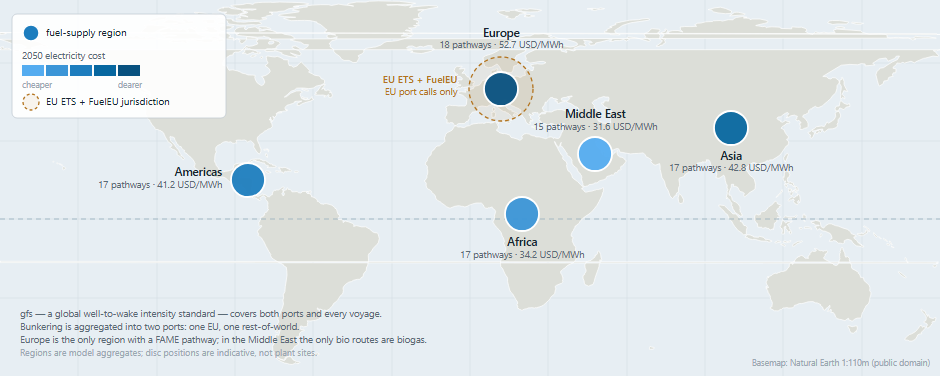

*The reference scenario's geography: five fuel-supply regions, the 2050 electricity
cost that feeds them, the production pathways each can host, and the EU jurisdiction
the ETS and FuelEU reach.*

This deck is different from the single-voyage illustrative case in [notebook 2](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/dev-workshop/docs/workshop/02-vessel-case-study.ipynb).
One big difference is that here, 23 fleets sail 23 routes with no endpoints, and bunkering is
aggregated into just two ports, one EU and one rest-of-world. So there is no line to
draw across the ocean. Instead, the routes in the model represent an averaged profile for the fleet.

The 84 plants in the deck are 18 production pathways replicated across five regions, less the six region-pathway combinations the deck leaves out. The difference between the copies is basically the cost of the electricity (the Middle East and Africa end up cheapest, Europe dearest, a spread of about 21 USD/MWh by 2050). Fuel logistics are not part of this simulation. The deck still loads `DefaultBunkerLogistics`, which sets no region-to-port distances, so all ten region-port pairs default to zero nautical miles at zero cost per ton-mile. Thus, for a world-level scenario, it is assumed that every region is equally close to both simulated ports.

Or in other words: geography does not really matter in this simulation.

## Setup (repeat if starting a fresh session)

Running this on Colab or locally? The [workshop overview](https://github.com/zerocarbonshipping/navigate-zcs/blob/dev-workshop/docs/workshop/index.md) explains both; the cell below handles either case without changes.

In [1]:
# Setup. Works both on Google Colab and in a local checkout of the repository;
# the workshop overview explains the two ways to run these notebooks.
import os
from pathlib import Path


# The branch these notebooks live on. Colab clones THIS branch, and the
# "Open in Colab" badge at the top of the notebook, like the links between the
# notebooks, points at the same one. Change all of them to "main" once the
# branch has been merged.
BRANCH = "dev-workshop"


def at_repo_root() -> bool:
    """True if the working directory is the root of the repository."""
    return Path("navigate").is_dir() and Path("assumptions").is_dir()


if at_repo_root():
    print("Already at the repository root.")
elif Path("../../navigate").is_dir():
    # Local Jupyter starts the kernel in the notebook's own folder,
    # docs/workshop/, but the paths below are relative to the repository root.
    os.chdir("../..")
    print("Moved up to the repository root.")
else:
    # Colab, or any other fresh environment
    if not Path("navigate-zcs").is_dir():
        !git clone --depth 1 -b {BRANCH} https://github.com/zerocarbonshipping/navigate-zcs.git
    os.chdir("navigate-zcs")
    print("Cloned the repository and moved into it.")

assert at_repo_root(), f"not at the repository root: {Path.cwd()}"

# `import navigate` is not a usable test here: from the repository root it
# succeeds because the source folder is present, which leaves the `navigate`
# command itself missing.
import sys
from importlib.metadata import PackageNotFoundError, version

try:
    print(f"Navigate {version('navigate-zcs')} is already installed.")
except PackageNotFoundError:
    %pip install -q .
    print("Installed Navigate.")

# The workshop's colours, shared with notebook 2 so the two cannot drift apart.
_STYLE_DIR = str(Path("docs/workshop").resolve())
if _STYLE_DIR not in sys.path:
    sys.path.insert(0, _STYLE_DIR)

from _style import (AXIS, GRID, INK, SUBINK, TICK, fuel_colour, fuel_label,
                    fuel_sorted, scen_colour)

Moved up to the repository root.
Navigate 1.0.0 is already installed.


## See what scenarios are available

Run this cell to check which of the Center's pre-made scenarios are available in the simulation folder.

In [2]:
import os

scenarios_dir = "simulations/scenarios"
scenario_names = sorted(
    d for d in os.listdir(scenarios_dir)
    # a scenario is a folder holding a deck of its own name; 0_includes is
    # shared includes, not a scenario
    if os.path.isfile(os.path.join(scenarios_dir, d, f"{d}.nav"))
)
print("Available reference scenarios:")
for s in scenario_names:
    print(" -", s)


Available reference scenarios:
 - basecase_mid_regulation
 - basecase_no_regulation
 - basecase_strong_regulation
 - business_as_usual


## A first look at the different scenarios

In these decks the regulation is the only thing that differs between scenarios. Check how the decks of each scenario are built: 

In [3]:
from pathlib import Path

deck_names = ["basecase_no_regulation", "basecase_mid_regulation", "basecase_strong_regulation"]


def deck_body(name):
    """A scenario's .nav file, minus the licence header, comments and blank lines."""
    text = Path(f"simulations/scenarios/{name}/{name}.nav").read_text(encoding="utf-8")
    return [line.strip() for line in text.splitlines()
            if line.strip() and not line.strip().startswith("#")]


for name in deck_names:
    print(f"{name}.nav")
    for line in deck_body(name):
        print("   ", line)
    print()

base = deck_body("basecase_no_regulation")
for name in deck_names[1:]:
    print(f"{name} adds to basecase_no_regulation:")
    for line in deck_body(name):
        if line not in base:
            print("   ", line)

print("\nbasecase_mid_regulation vs basecase_strong_regulation differ only in:")
mid_body = deck_body("basecase_mid_regulation")
for line in deck_body("basecase_strong_regulation"):
    if line not in mid_body:
        print("   ", line)


basecase_no_regulation.nav
    DEFINE {
    Load DefaultModelDefinition
    Load DefaultBunkerLogistics
    Load DefaultFleet
    Load DefaultPort
    Load DefaultEmission
    Load DefaultFeedstock
    Load DefaultFuel
    Load DefaultProducer
    Load DefaultPlant
    Load DefaultRegion
    Load DefaultSource
    Load DefaultTransport
    Load DefaultCalibration
    Load DefaultReport
    Load DefaultPlot
    Load DebugPlot
    }
    EVENTS {
    Load DefaultConverterAvailable
    Load DefaultTimeStepYearly
    }

basecase_mid_regulation.nav
    DEFINE {
    Load DefaultModelDefinition
    Load DefaultBunkerLogistics
    Load DefaultFleet
    Load DefaultPort
    Load DefaultEmission
    Load DefaultFeedstock
    Load DefaultFuel
    Load DefaultProducer
    Load DefaultPlant
    Load DefaultRegion
    Load DefaultSource
    Load DefaultTransport
    Load DefaultRegulation
    Include "../0_includes/mid_regulation.inc"
    Load DefaultCalibration
    Load DefaultReport
    Load Defaul

The main difference between the scenarios is the implemented regulation, and it comes down to
the two lines the diff above picked out. `Load DefaultRegulation` pulls the EU ETS and FuelEU
Maritime regulations out of the assumptions library, and the `Include` line adds one
scenario-specific file on top. So `basecase_no_regulation` carries no regulation at all, not the
ETS, not FuelEU, not a global standard, while the other two carry all three and differ only in
what that included file asks for.

In these example decks that scenario-specific regulation is a **Global Fuel Standard** type of regulation.

A Global Fuel Standard (GFS) is a worldwide limit on the greenhouse-gas intensity of the fuel a ship burns, tightening year on year, with penalties for exceeding the limit and rewards for using cleaner fuels. It is relatively similar to the EU FuelEU Maritime regulation, but applies worldwide rather than only to EU/EEA ports. It is a modelling assumption in these decks, not an adopted rule.


`gfs_target_reduction` is the well-to-wake GHG intensity limit every vessel is measured against, and
`gfs_remedial_unit` is the penalty for missing it. Both are defined per scenario in `simulations/scenarios/0_includes/{mid,strong}_regulation.inc`, so we can parse both decks and compare their regulatory assumptions side by side.

——————————————————————————————————————————————————————————————————————————————————————————————————
            |    |    |                                  .oO
           )_)  )_)  )_)                             __/___                  _    _
          )___))___))___)\                     _____/______|              __|_|__|_|__
         )____)____)_____)\\           _______/_____\_______\_____      _|____________|__
       _____|____|____|____\\\__       \              < < <       |    |o o o o o o o o /
~~~~~~~\                   /~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        ´´´´´´´´´´´´´´´´´´´              Navigate
——————————————————————————————————————————————————————————————————————————————————————————————————
        Navigate - an integrated assessment model for decarbonizing shipping
        Developed by Fonden Mærsk Mc-Kinney Møller Center for Zero Carbon Shipping
        Version 1.0.0 - for questions, contact navigate@zerocarbonshipping.com


——————————————————————————————————————————————————————————————————————————————————————————————————
            |    |    |                                  .oO
           )_)  )_)  )_)                             __/___                  _    _
          )___))___))___)\                     _____/______|              __|_|__|_|__
         )____)____)_____)\\           _______/_____\_______\_____      _|____________|__
       _____|____|____|____\\\__       \              < < <       |    |o o o o o o o o /
~~~~~~~\                   /~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        ´´´´´´´´´´´´´´´´´´´              Navigate
——————————————————————————————————————————————————————————————————————————————————————————————————
        Navigate - an integrated assessment model for decarbonizing shipping
        Developed by Fonden Mærsk Mc-Kinney Møller Center for Zero Carbon Shipping
        Version 1.0.0 - for questions, contact navigate@zerocarbonshipping.com


basecase_mid_regulation resolves 447 Forecast, 137 Curve, 30 Timetable and 8 Surface nodes

  Fuel oil (USD/ton)                 485.0 (2026)  ->    485.0 (2050)
  LNG (USD/ton)                      436.0 (2026)  ->    436.0 (2050)
  European electricity (USD/MWh)      77.1 (2025)  ->     52.7 (2050)

what the two regulation scenarios ask for, by 2050:
  GHG intensity limit      mid        28.0 gCO2eq/MJ
  GHG intensity limit      strong      0.0 gCO2eq/MJ
  penalty for missing it   mid       300.0 USD/t
  penalty for missing it   strong    800.0 USD/t


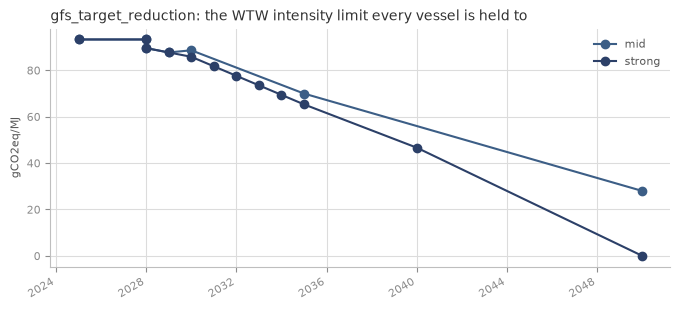

In [4]:
import argparse
from pathlib import Path

import pandas as pd
from navigate.manager import SimulationManager

# Same arguments the CLI would build from `-d ./assumptions`. No `-e`, because we
# are not calling manager.run() at all.
PARSE_ARGS = argparse.Namespace(data_dir=Path("./assumptions"), solver=None)


def parse_scenario(name):
    """Read a scenario deck's nodes without solving it."""
    m = SimulationManager()
    m.read_deck(Path(f"simulations/scenarios/{name}/{name}.nav"), PARSE_ARGS)
    return m


def forecast_to_frame(name, nodes):
    """A Forecast node's resolved (date, value) table, as in notebook 2."""
    node = nodes.forecasts[name]
    return pd.DataFrame({"date": pd.to_datetime(node.get_x_date()),
                         "value": [node.calculate(x) for x in node.get_x()]})


mid = parse_scenario("basecase_mid_regulation")
strong = parse_scenario("basecase_strong_regulation")

print(f"basecase_mid_regulation resolves {len(mid.nodes.forecasts)} Forecast, "
      f"{len(mid.nodes.curves)} Curve, {len(mid.nodes.timetables)} Timetable and "
      f"{len(mid.nodes.surfaces)} Surface nodes\n")

# the global prices every scenario shares
for name, label in [("fossil_fuel_oil_price_global", "Fuel oil (USD/ton)"),
                    ("liquefied_natural_gas_price_global", "LNG (USD/ton)"),
                    ("electricity_cost_europe_mid", "European electricity (USD/MWh)")]:
    df = forecast_to_frame(name, mid.nodes)
    print(f"  {label:32} {df['value'].iloc[0]:7.1f} ({df['date'].iloc[0].year})"
          f"  ->  {df['value'].iloc[-1]:7.1f} ({df['date'].iloc[-1].year})")

# and the two regulatory assumptions that separate the scenarios
print("\nwhat the two regulation scenarios ask for, by 2050:")
for name, label, unit in [("gfs_target_reduction", "GHG intensity limit", "gCO2eq/MJ"),
                          ("gfs_remedial_unit", "penalty for missing it", "USD/t")]:
    for scenario_name, nodes in (("mid", mid.nodes), ("strong", strong.nodes)):
        df = forecast_to_frame(name, nodes)
        print(f"  {label:24} {scenario_name:7} {df['value'].iloc[-1]:7.1f} {unit}")

# The .inc tables hold a fraction of the 2025 intensity, but the node also sets
# Multiplier = 93.3 and `calculate()` applies it, so everything printed and plotted
# here is already an absolute well-to-wake intensity in gCO2eq/MJ.

# the same two scenario colours the comparison figure at the end of this
# notebook uses, so "strong" is the same blue in both
ax = forecast_to_frame("gfs_target_reduction", mid.nodes).plot(
    x="date", y="value", marker="o", label="mid", figsize=(8, 3.5),
    color=scen_colour("basecase_mid_regulation"))
forecast_to_frame("gfs_target_reduction", strong.nodes).plot(
    x="date", y="value", marker="o", label="strong", ax=ax,
    color=scen_colour("basecase_strong_regulation"))
ax.set_title("gfs_target_reduction: the WTW intensity limit every vessel is held to",
             fontsize=10, color=INK, loc="left")
ax.set_xlabel("")
ax.set_ylabel("gCO2eq/MJ", fontsize=8, color=SUBINK)
ax.legend(fontsize=8, frameon=False, labelcolor=SUBINK)
ax.grid(color=GRID, lw=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors=TICK, labelsize=8)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(AXIS)


## Run the scenarios

Run the next cell to solve the three scenarios in parallel.
Since this step takes a while, run it at the beginning of the workshop and come back to it later!

In [5]:
import subprocess
import sys
import time
import os

# the same three decks as above
deck_names = ["basecase_no_regulation", "basecase_mid_regulation", "basecase_strong_regulation"]

nav_files = {}
for name in deck_names:
    nav_file = f"simulations/scenarios/{name}/{name}.nav"
    assert os.path.exists(nav_file), f"Expected .nav file not found: {nav_file} -- check the scenario folder structure"
    nav_files[name] = nav_file

# the scenario the rest of this notebook inspects
scenario = "basecase_mid_regulation"

# This is the ~22 minute step: all three decks run at once.
processes = {}
console_logs = {}
started = time.time()

try:
    for name, nav_file in nav_files.items():
        console_path = f"simulations/scenarios/{name}/{name}_console.log"
        console_logs[name] = open(console_path, "w", encoding="utf-8")
        processes[name] = subprocess.Popen(
            [sys.executable, "-m", "navigate", nav_file, "-d", "./assumptions", "-e"],
            stdout=console_logs[name],
            stderr=subprocess.STDOUT,
        )
        print(f"started {name} (pid {processes[name].pid}) -> {console_path}")

    print("\nwaiting for all three to finish ...")
    for name, process in processes.items():
        code = process.wait()
        status = "ok" if code == 0 else f"FAILED (exit {code})"
        print(f"  {name:28} {status:20} {time.time() - started:6.0f} s elapsed")
finally:
    for handle in console_logs.values():
        handle.close()


started basecase_no_regulation (pid 34392) -> simulations/scenarios/basecase_no_regulation/basecase_no_regulation_console.log
started basecase_mid_regulation (pid 11616) -> simulations/scenarios/basecase_mid_regulation/basecase_mid_regulation_console.log
started basecase_strong_regulation (pid 6920) -> simulations/scenarios/basecase_strong_regulation/basecase_strong_regulation_console.log

waiting for all three to finish ...


  basecase_no_regulation       ok                      557 s elapsed


  basecase_mid_regulation      ok                     1254 s elapsed


  basecase_strong_regulation   ok                     1277 s elapsed


## Inspect the output plots

We read `basecase_mid_regulation`'s output here; the comparison at the end of
this notebook puts all three scenarios together.

The scenario decks load `DefaultPlot`, so the exact set of plots produced
depends on that default module — rather than assume its contents, we display
whatever image files land in the scenario's `plots/` folder. Every plot label
you might see is documented, grouped by category, in the reference manual's
[Plot Node Labels](https://zerocarbonshipping.github.io/navigate-zcs/reference_manual/plot.html)
appendix — e.g. `global_fuel_consumed` for the fuel mix, `global_emission_absolute`
for emissions, or `regulation_compliance` for how the "gfs" regulation binds.

### Engine fuel consumed

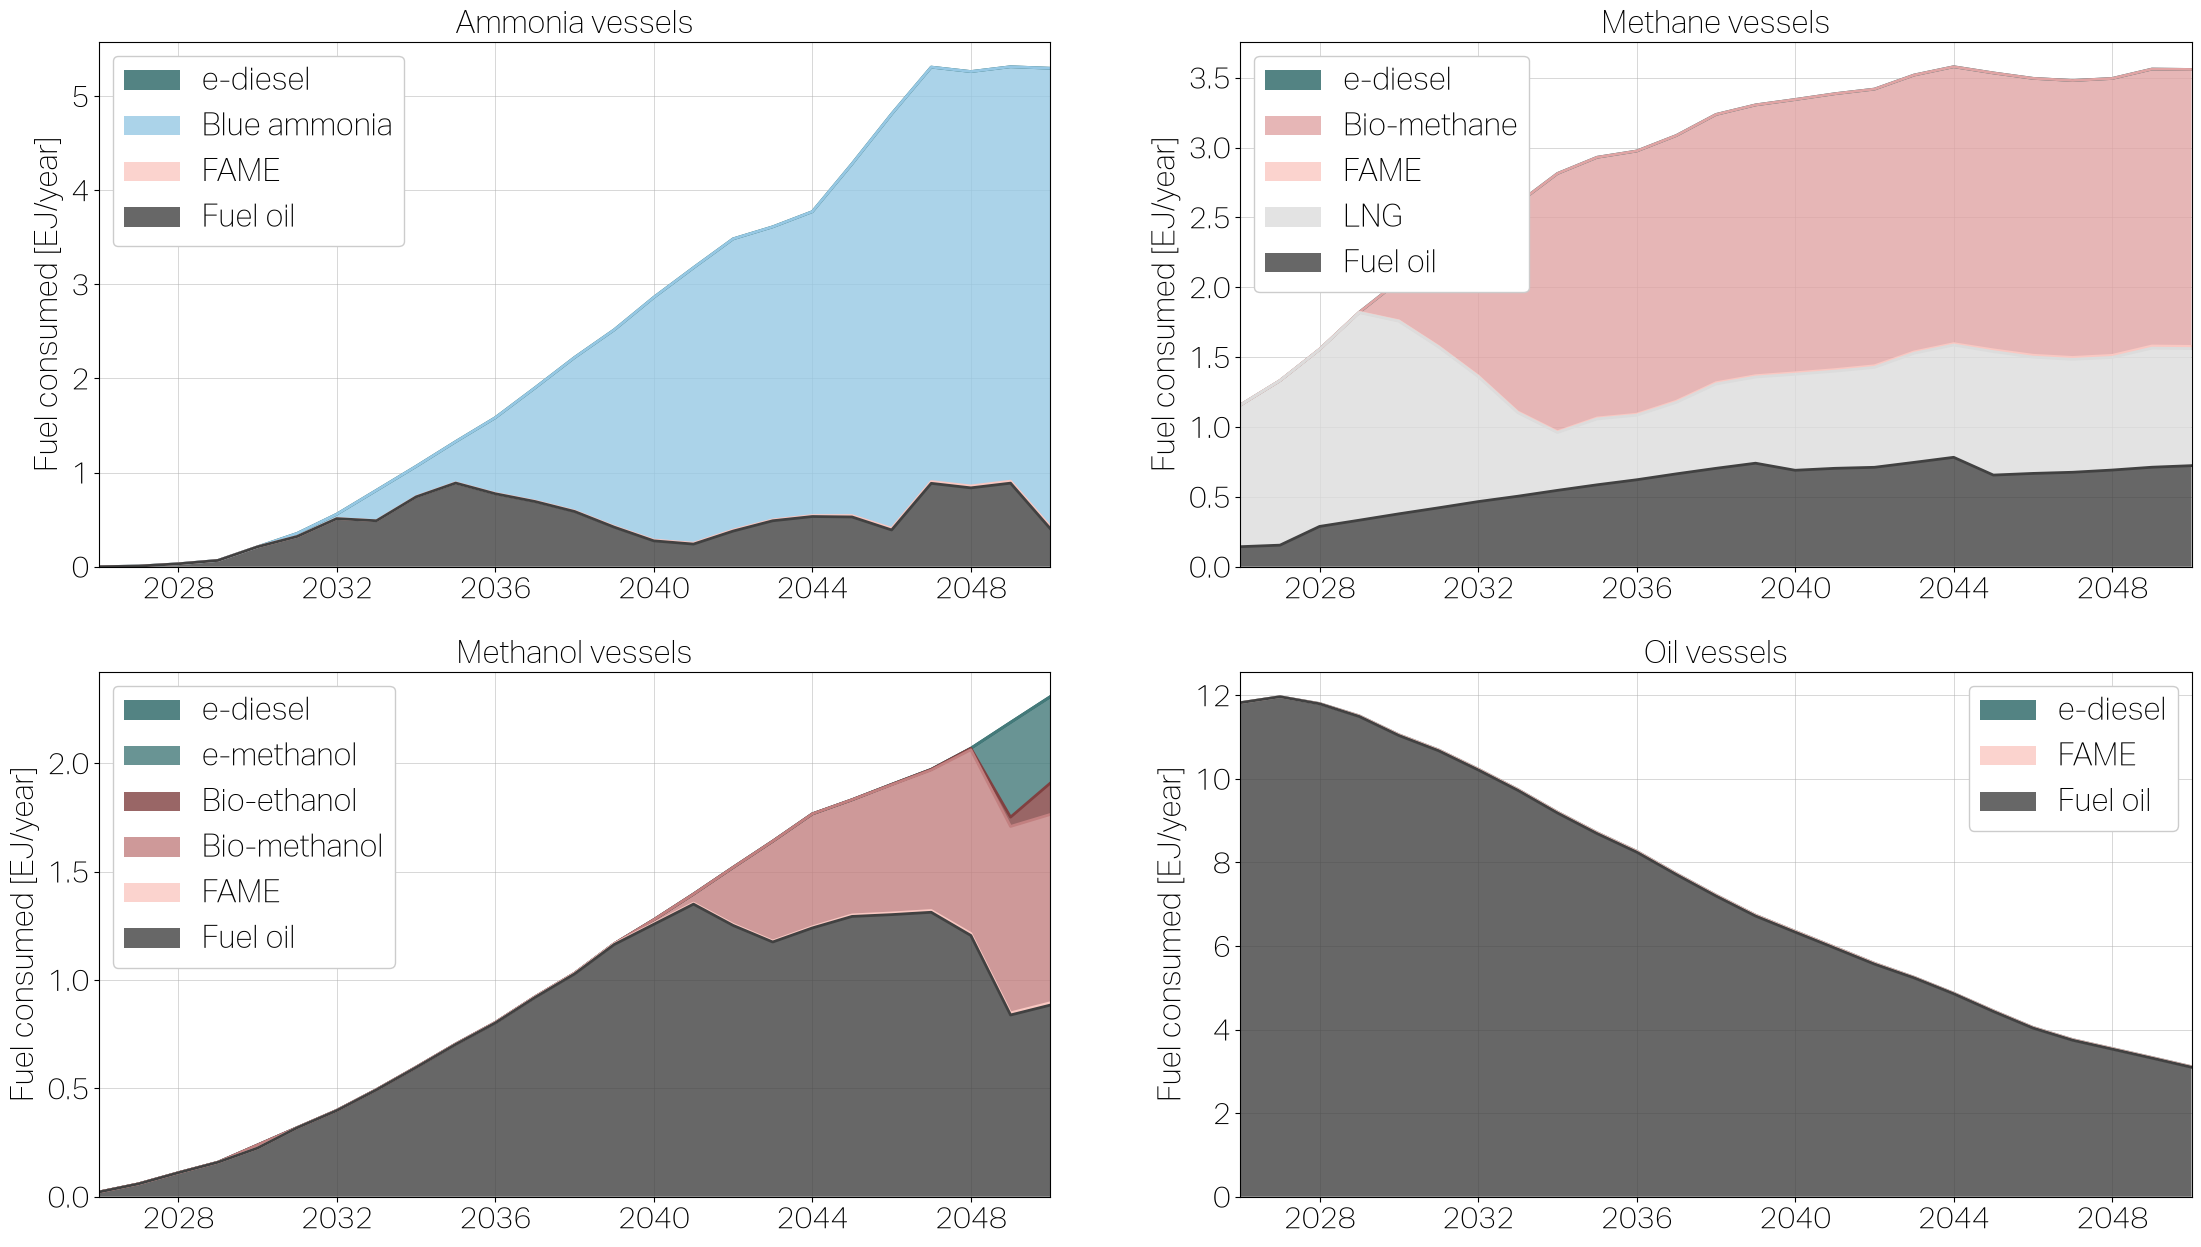

### Fuel type supply demand

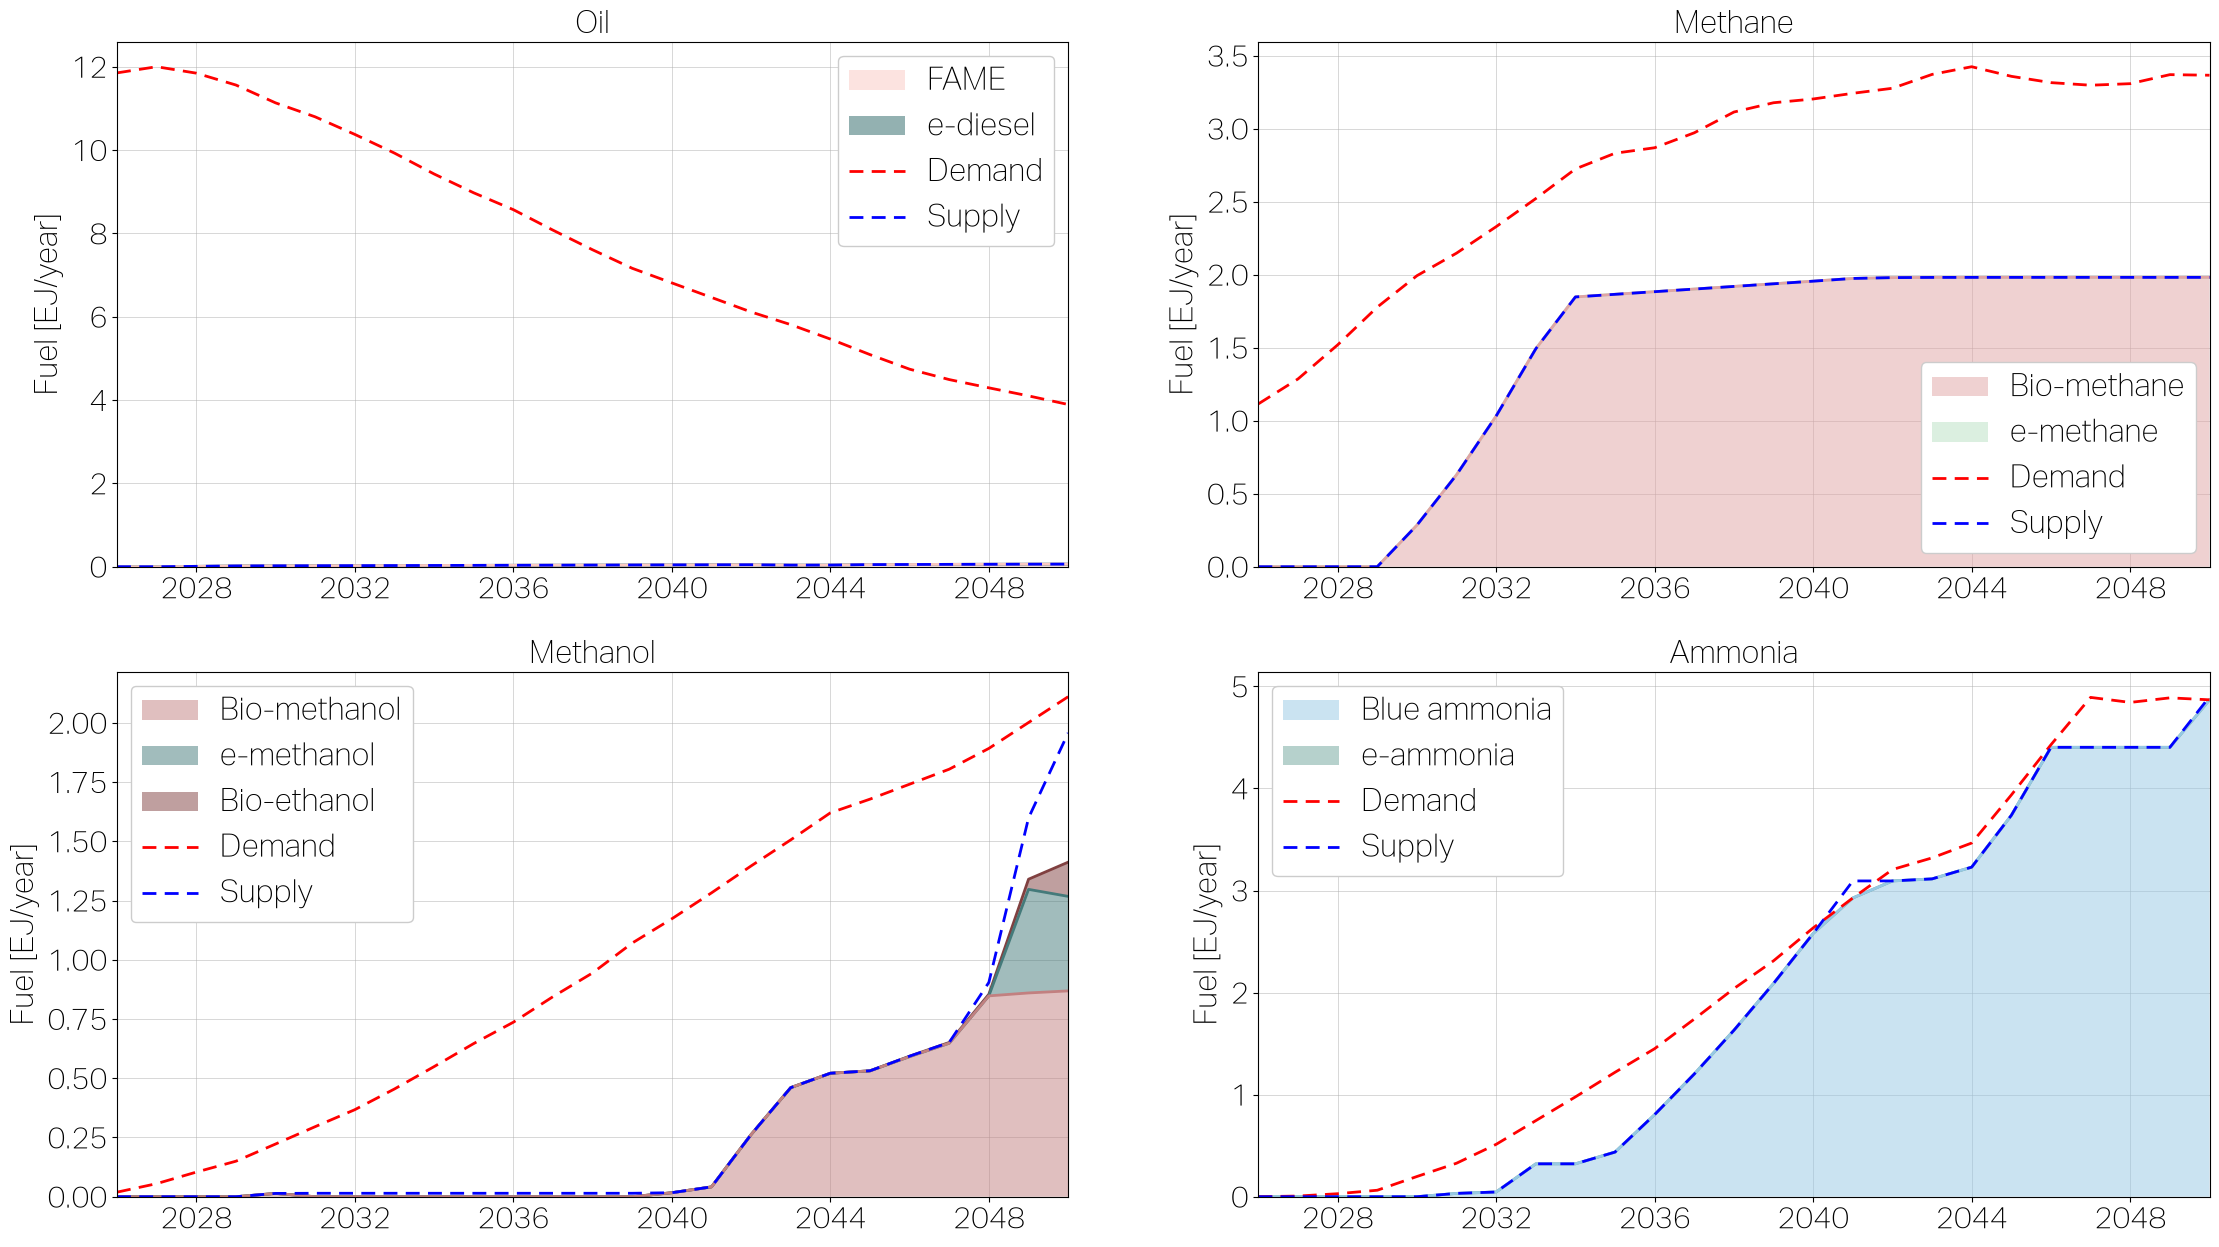

### Global emission absolute

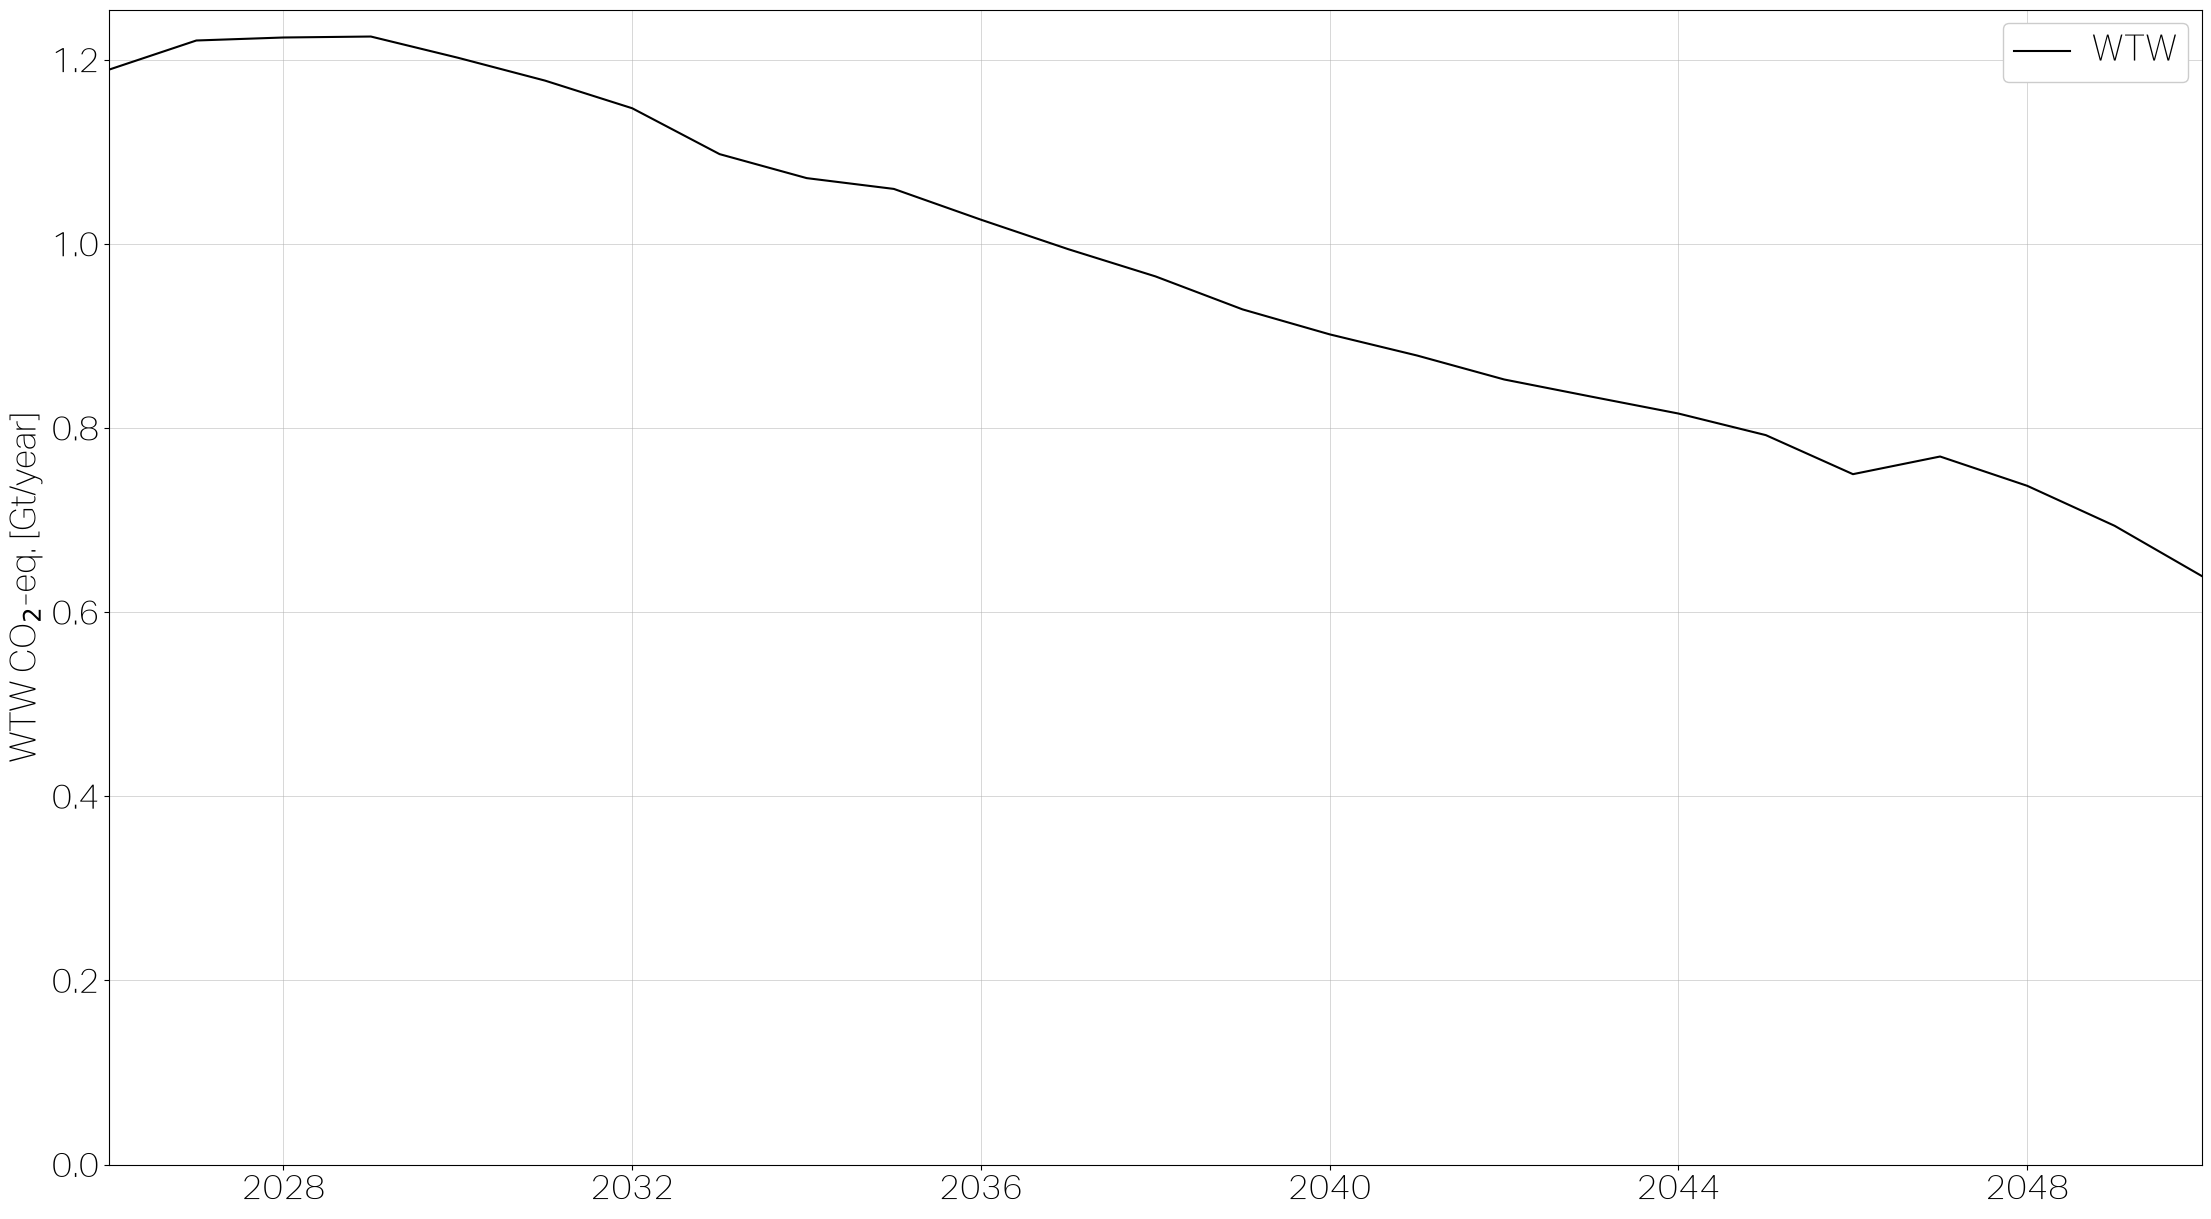

### Global energy saving

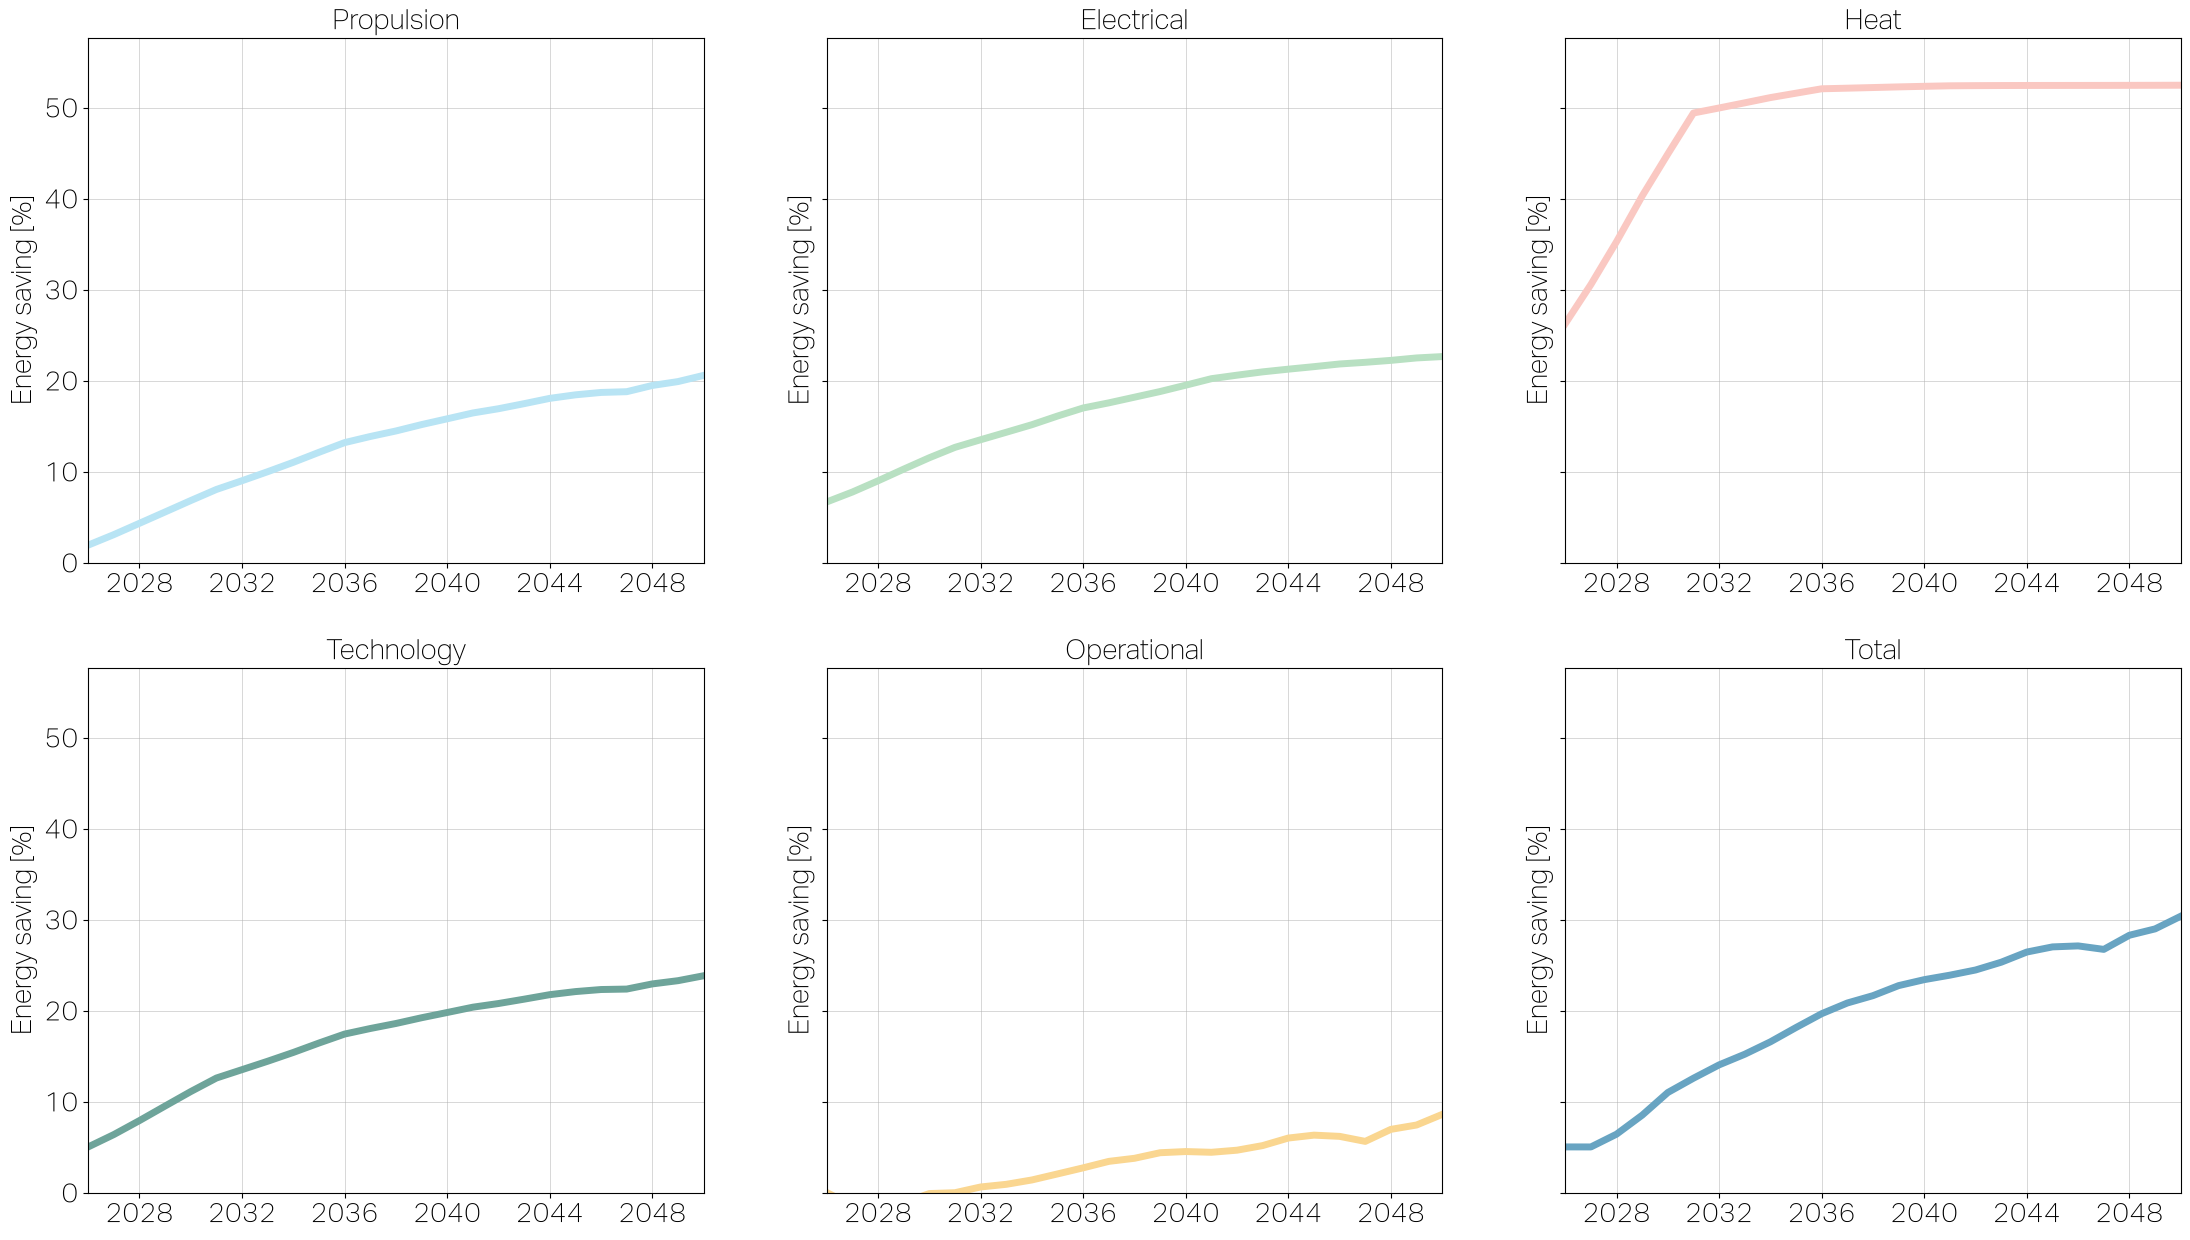

### Global fuel consumed

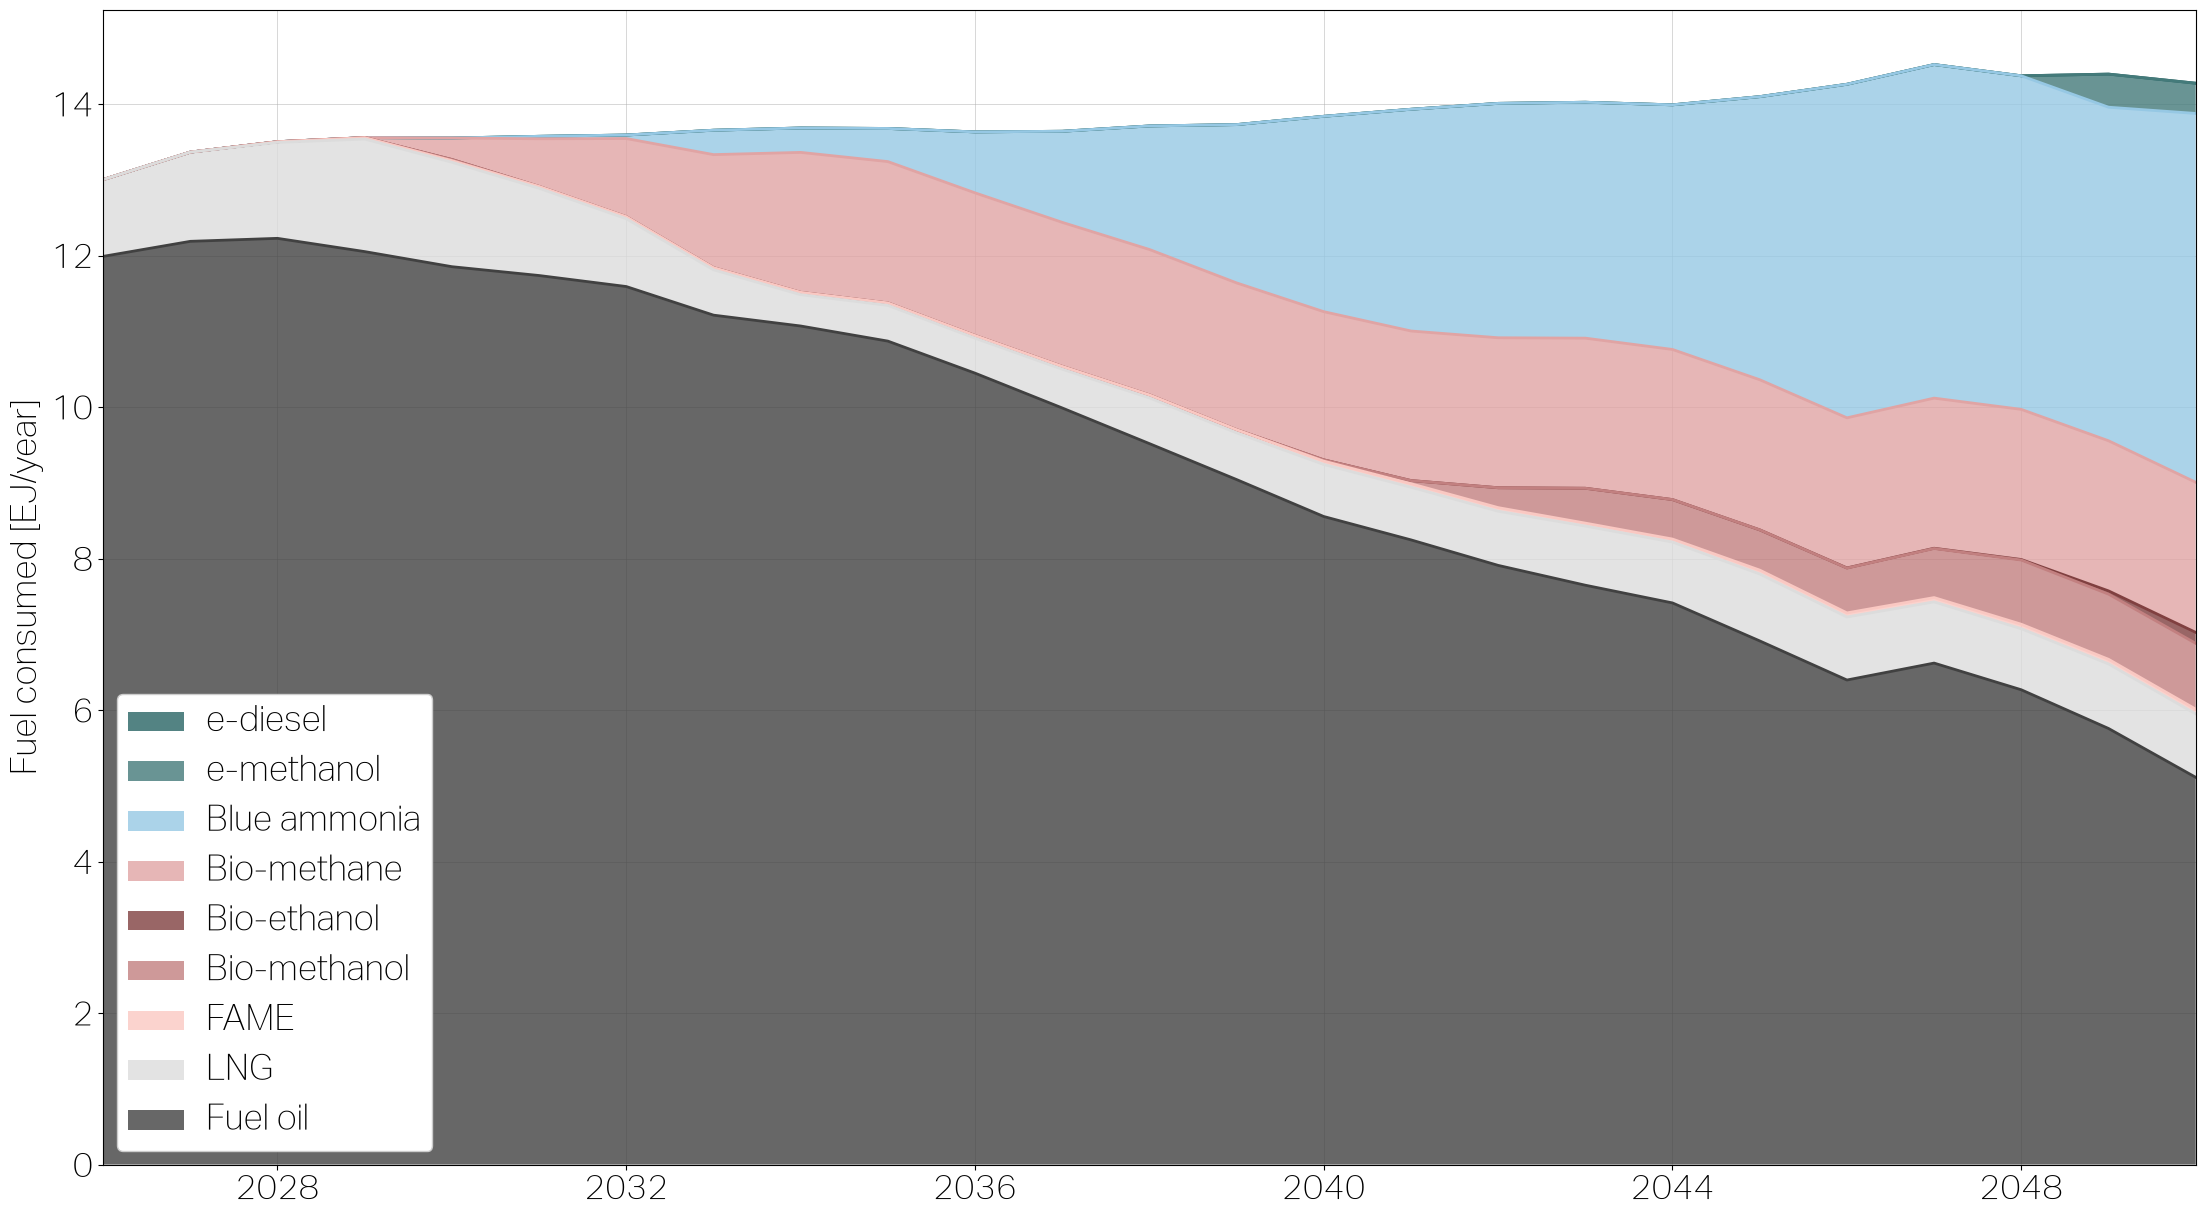

### Global installed power

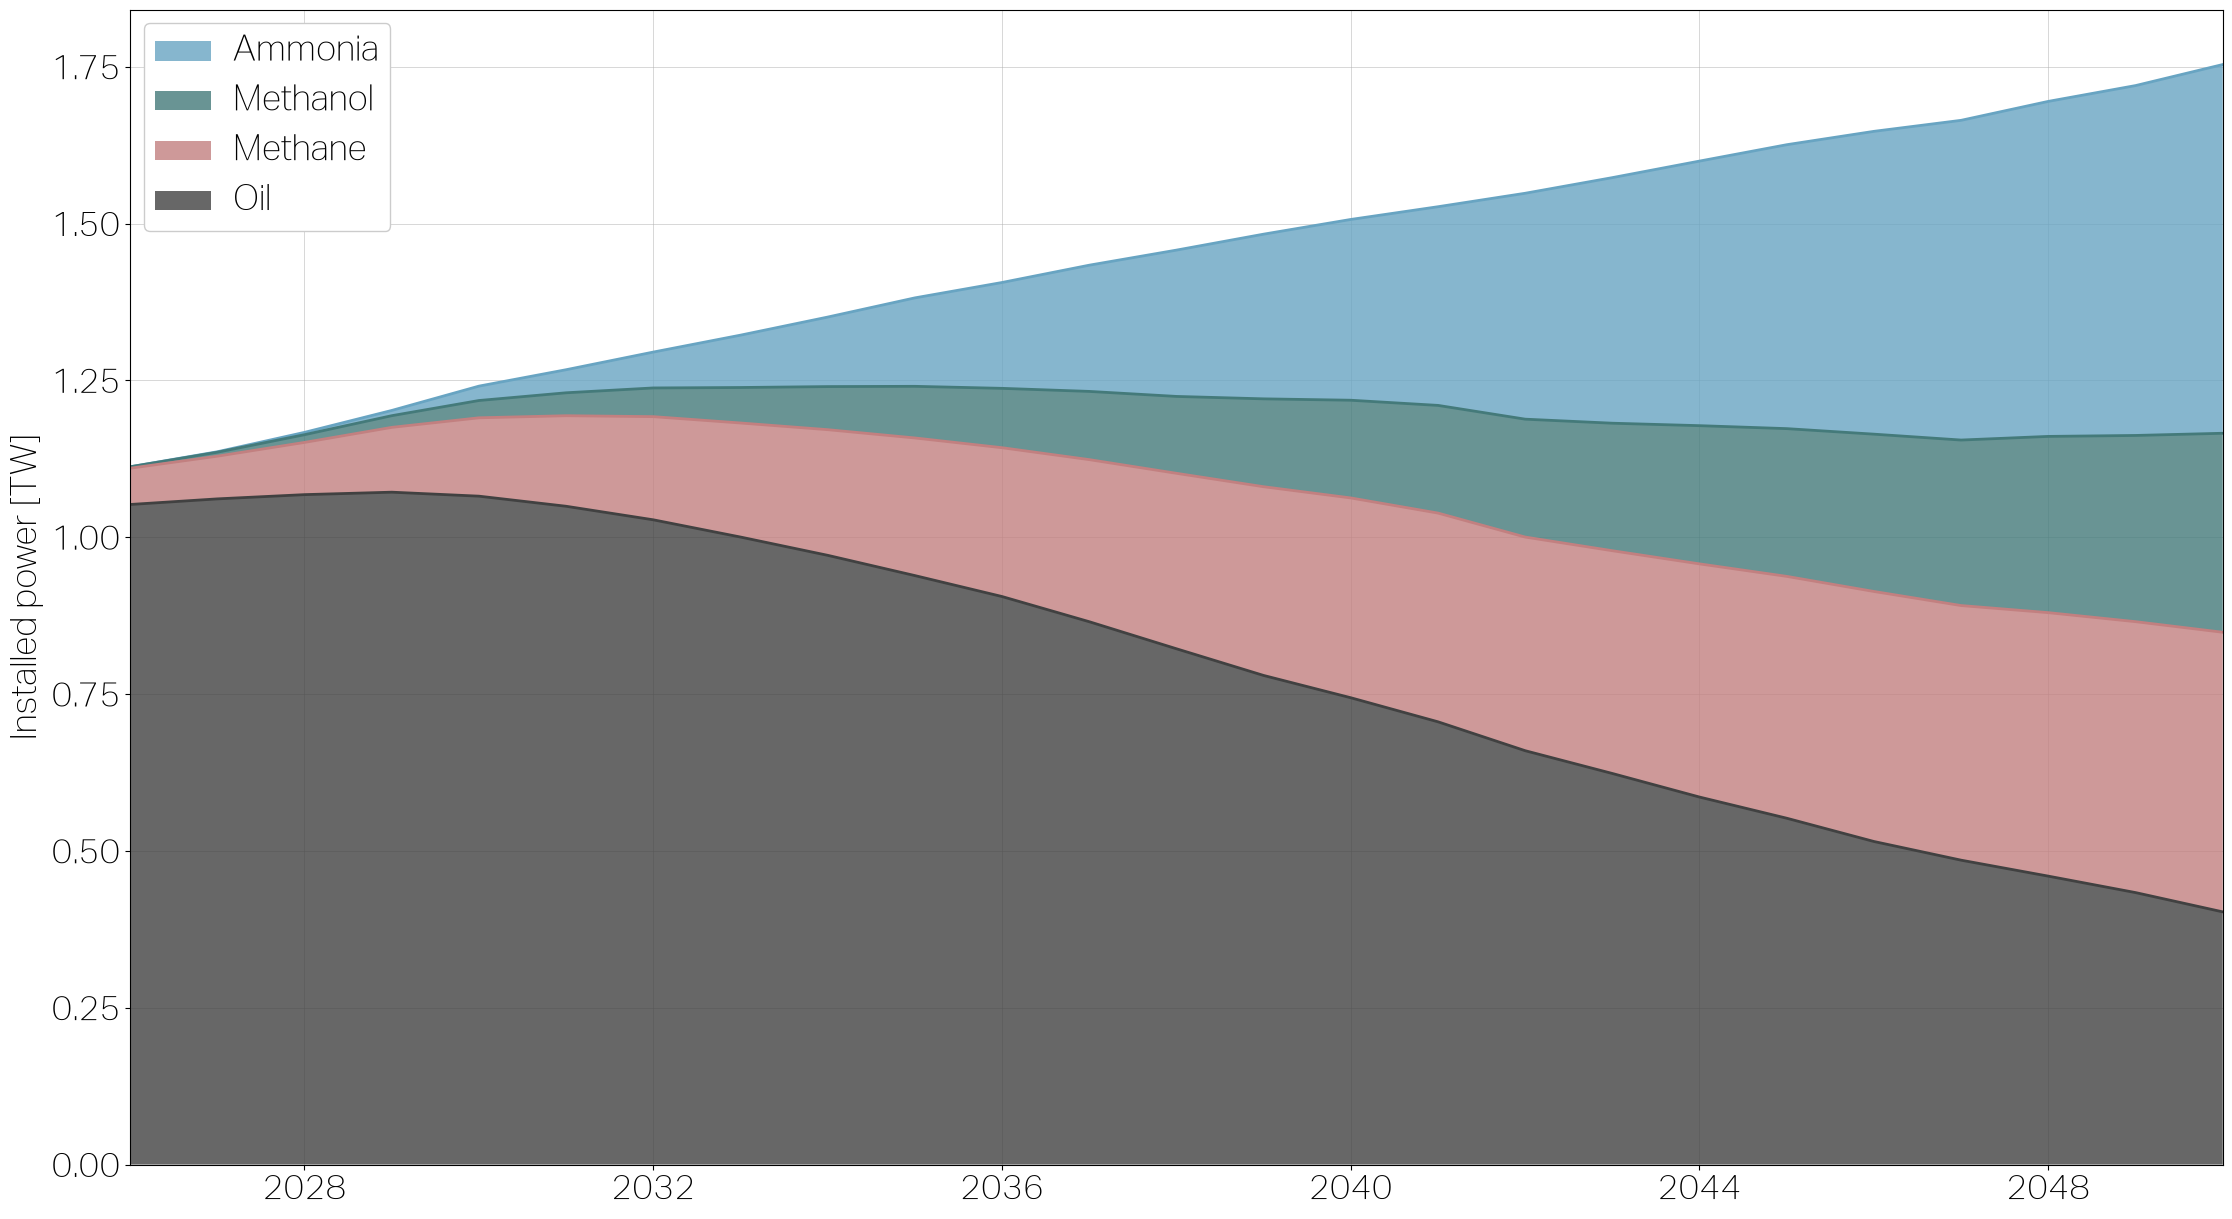

### Producer development

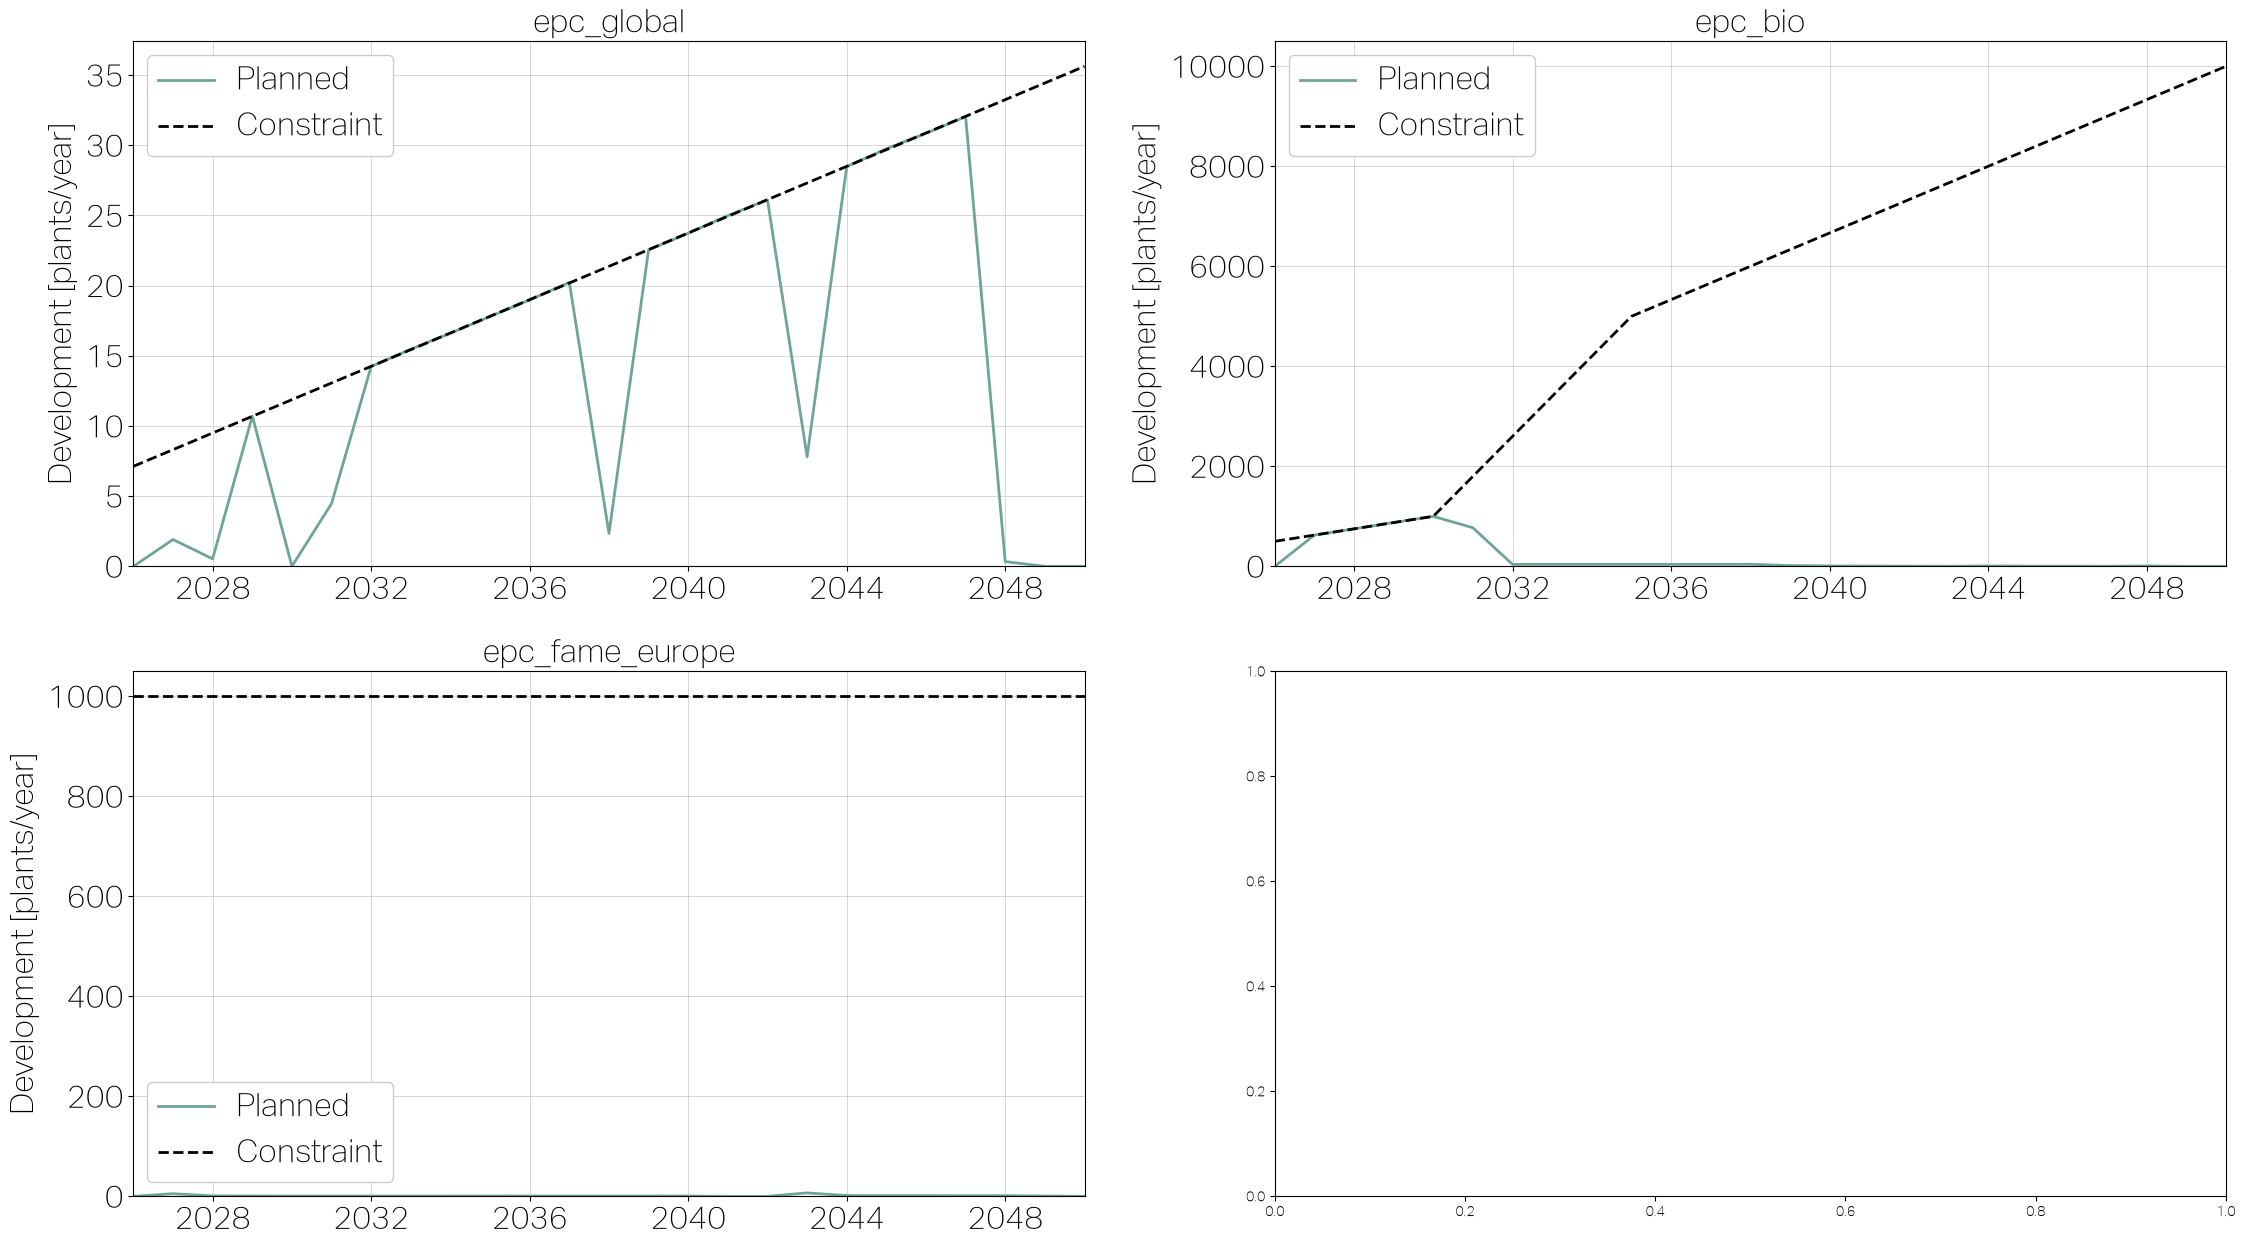

### Regulation compliance eu ets

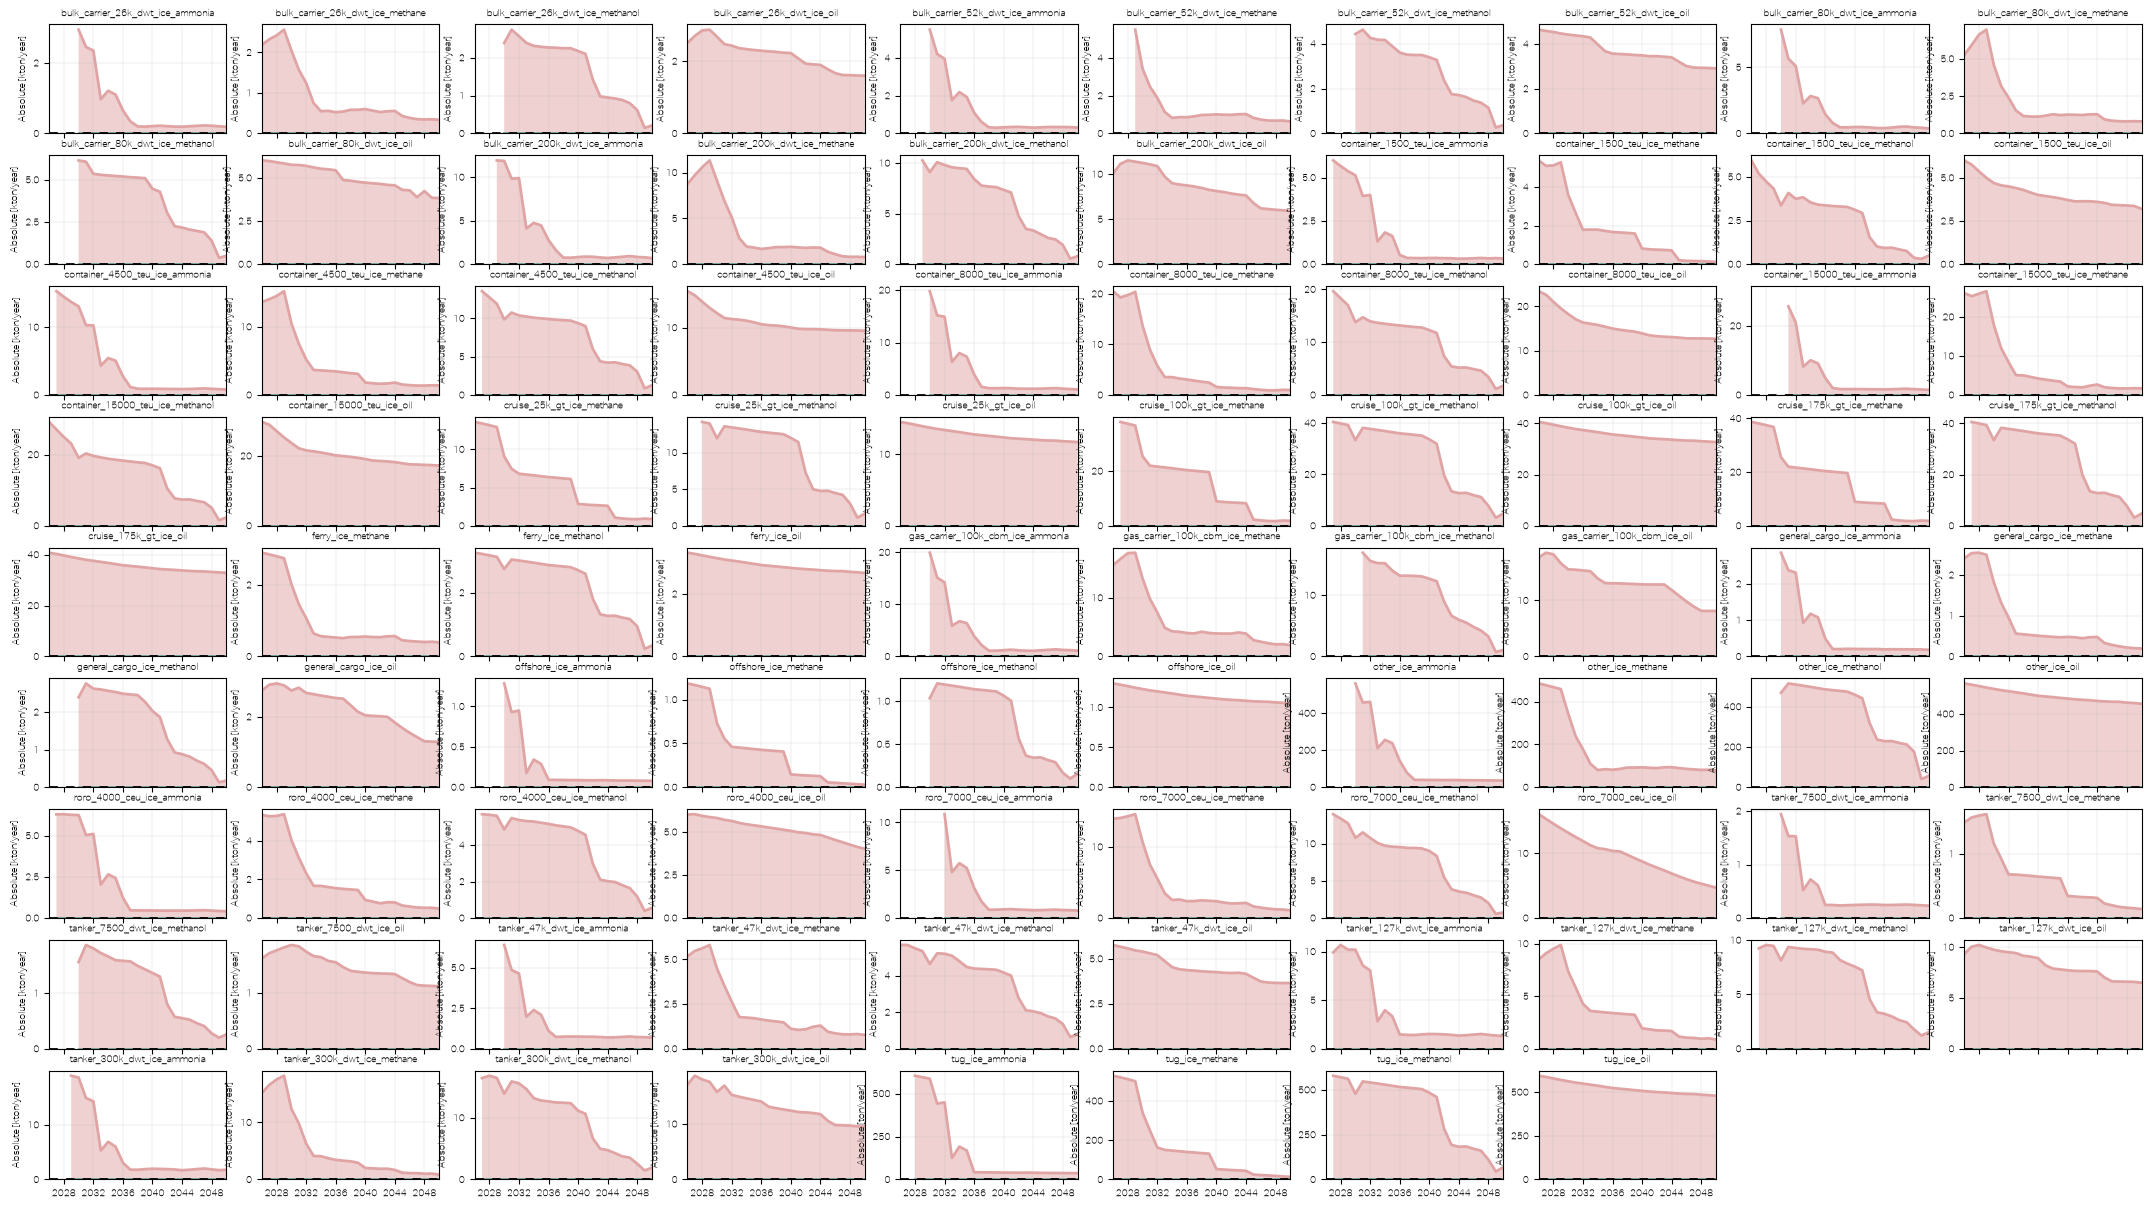

### Regulation compliance fuel eu

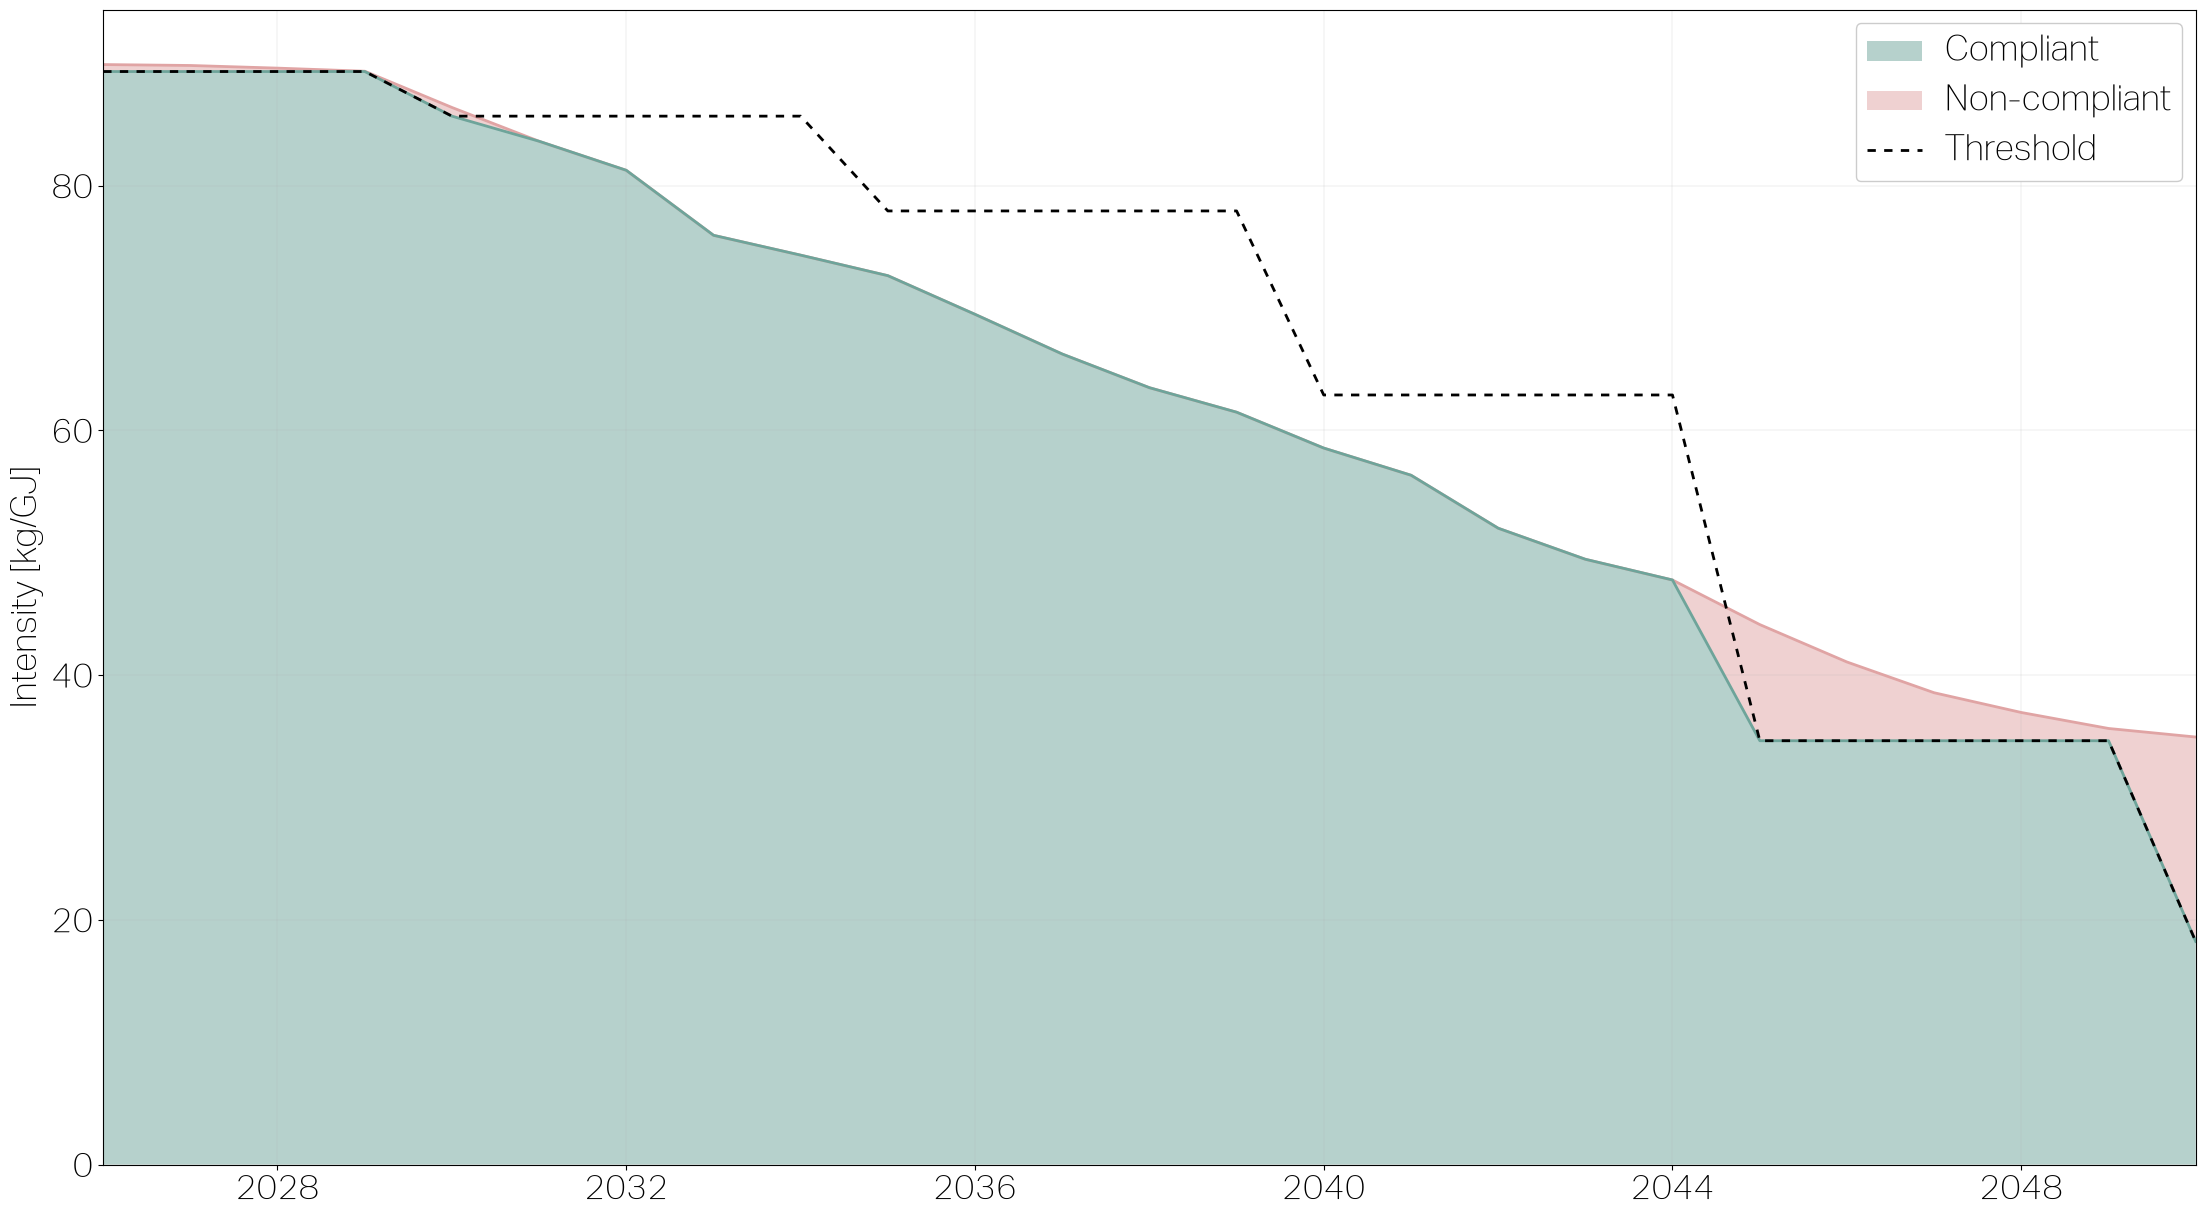

### Regulation compliance gfs

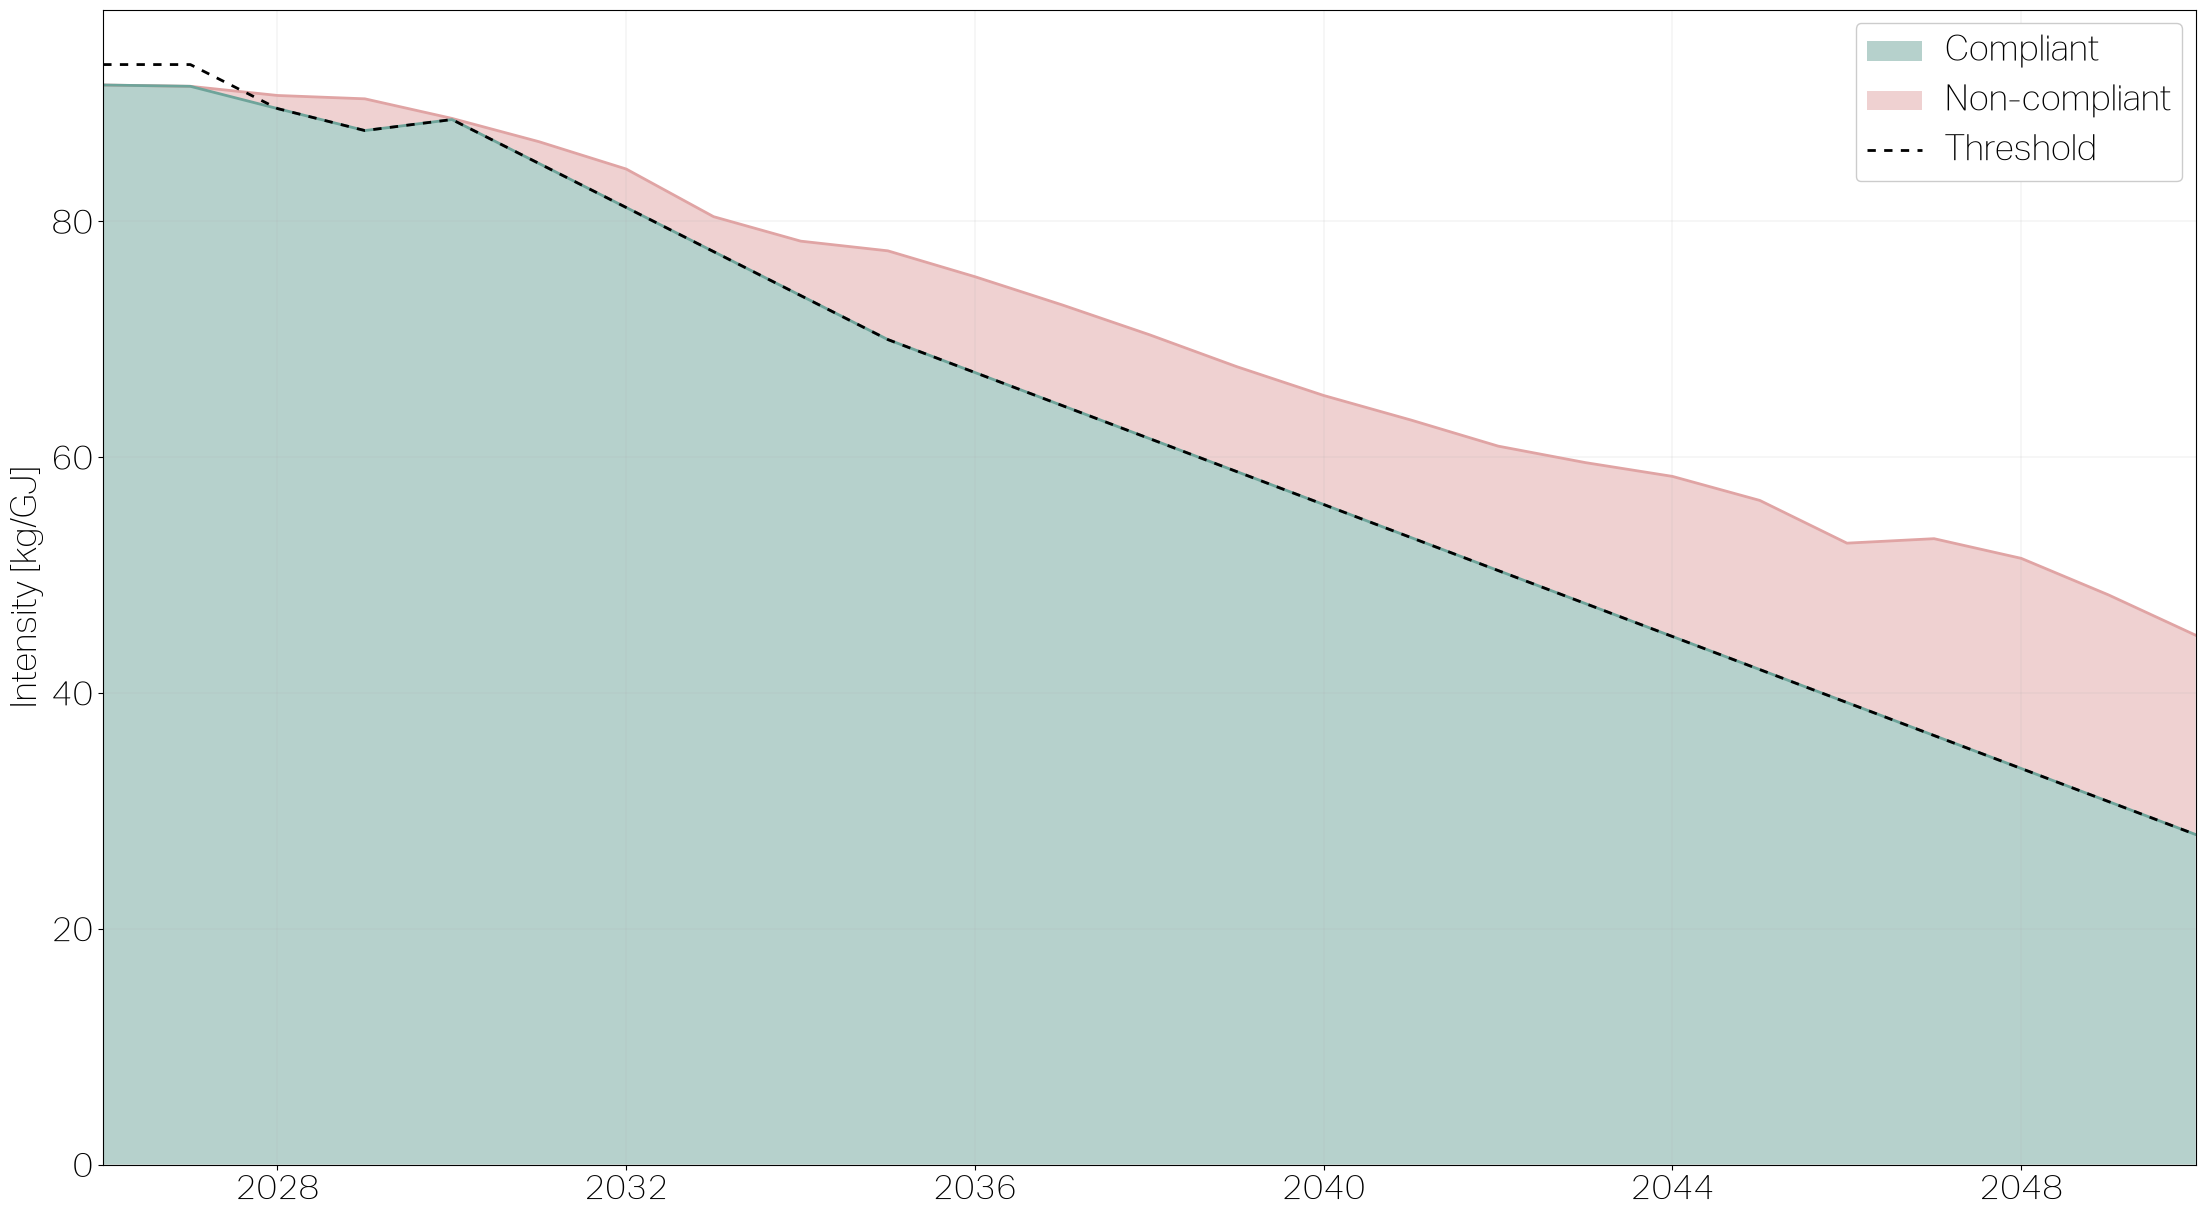

### Regulation flexibility cost fuel eu

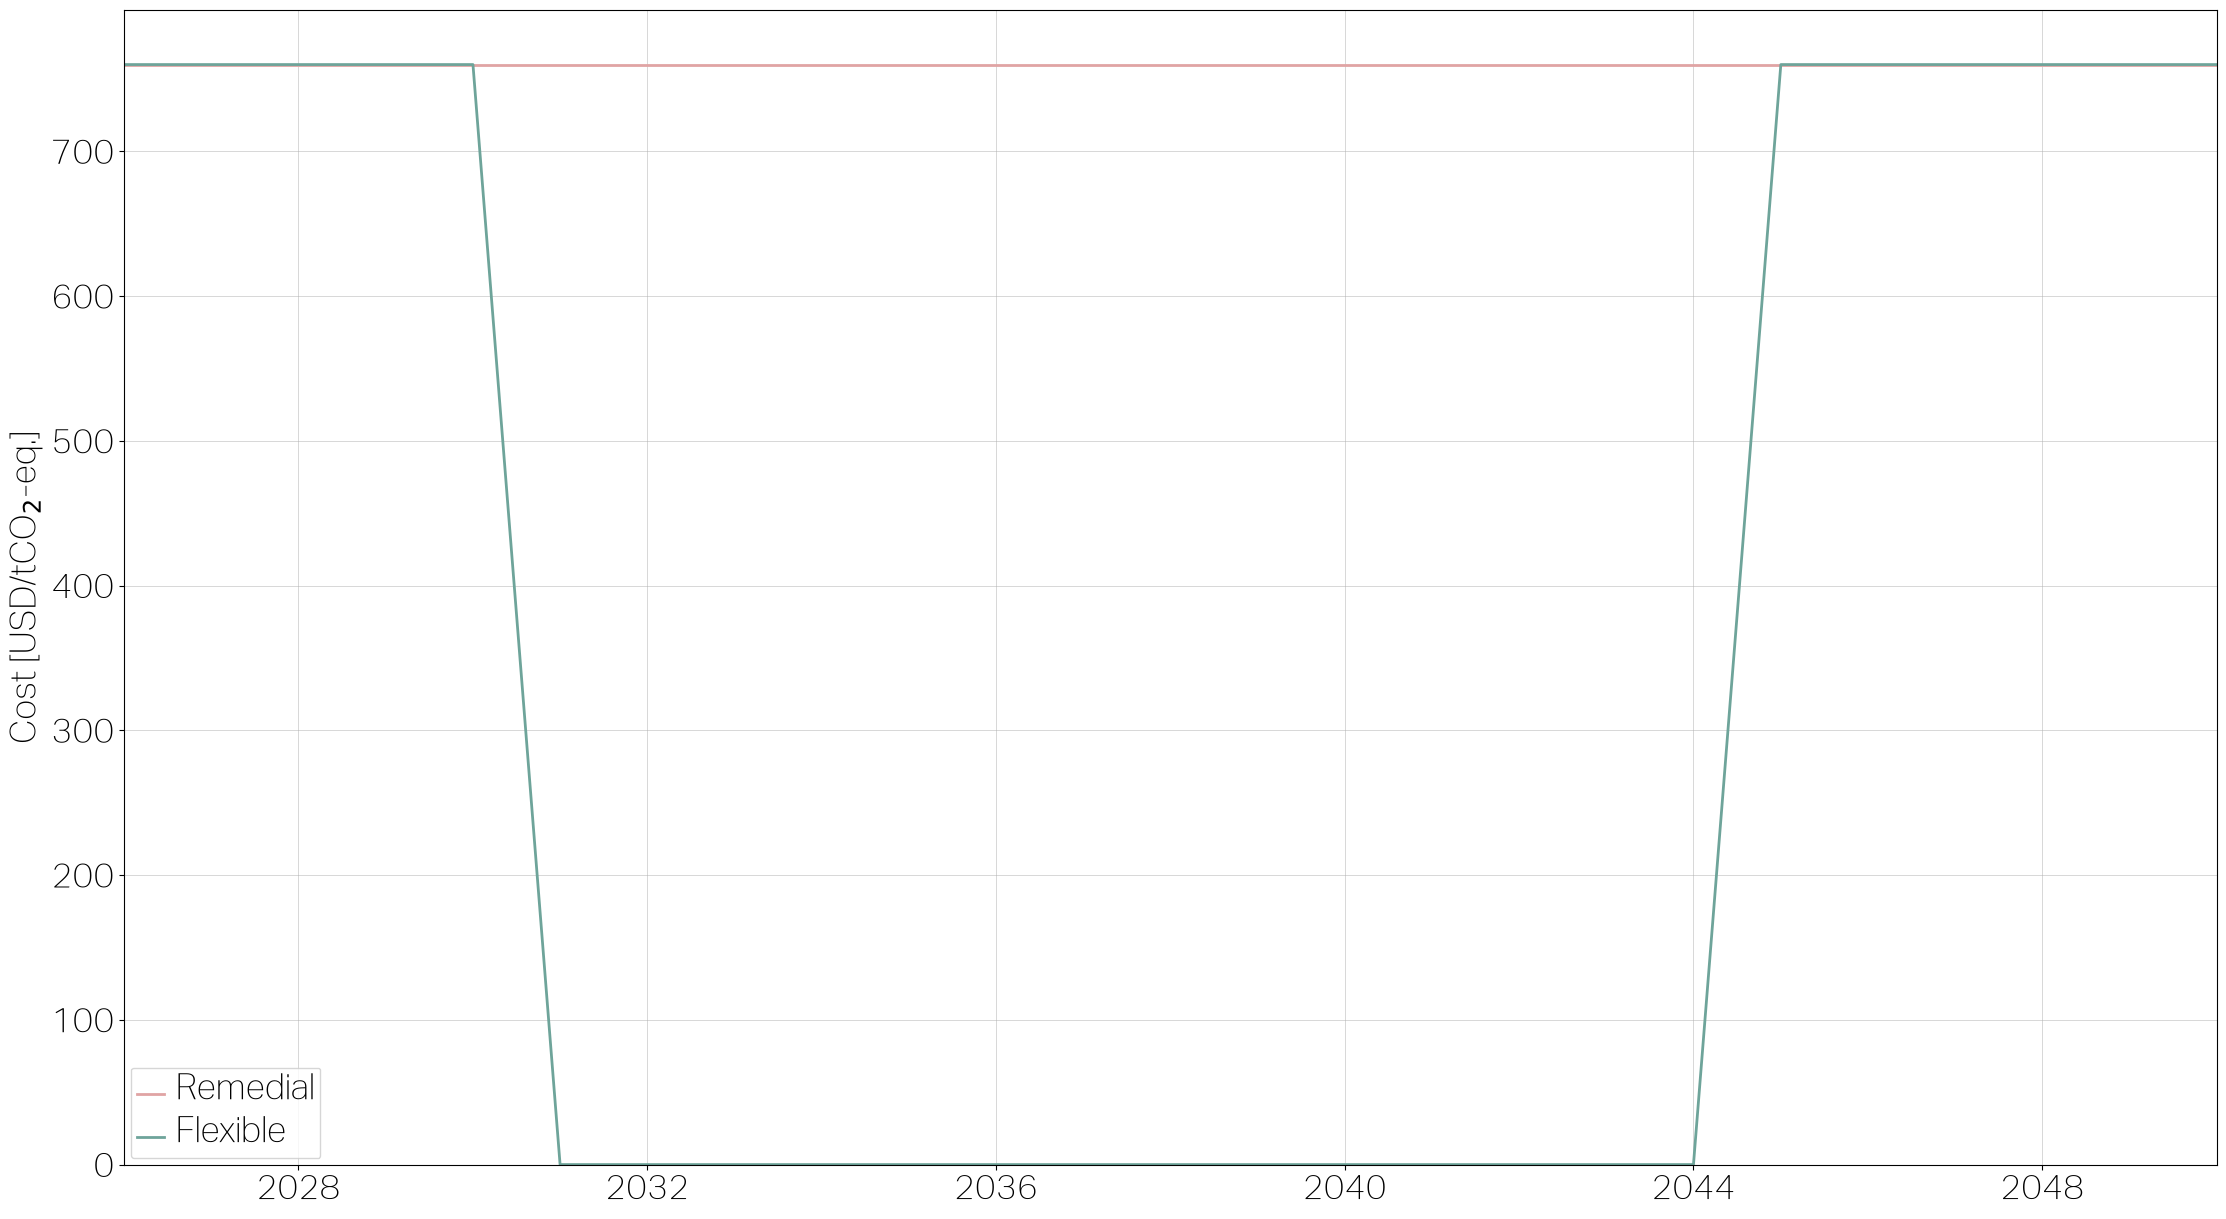

### Regulation flexibility cost gfs

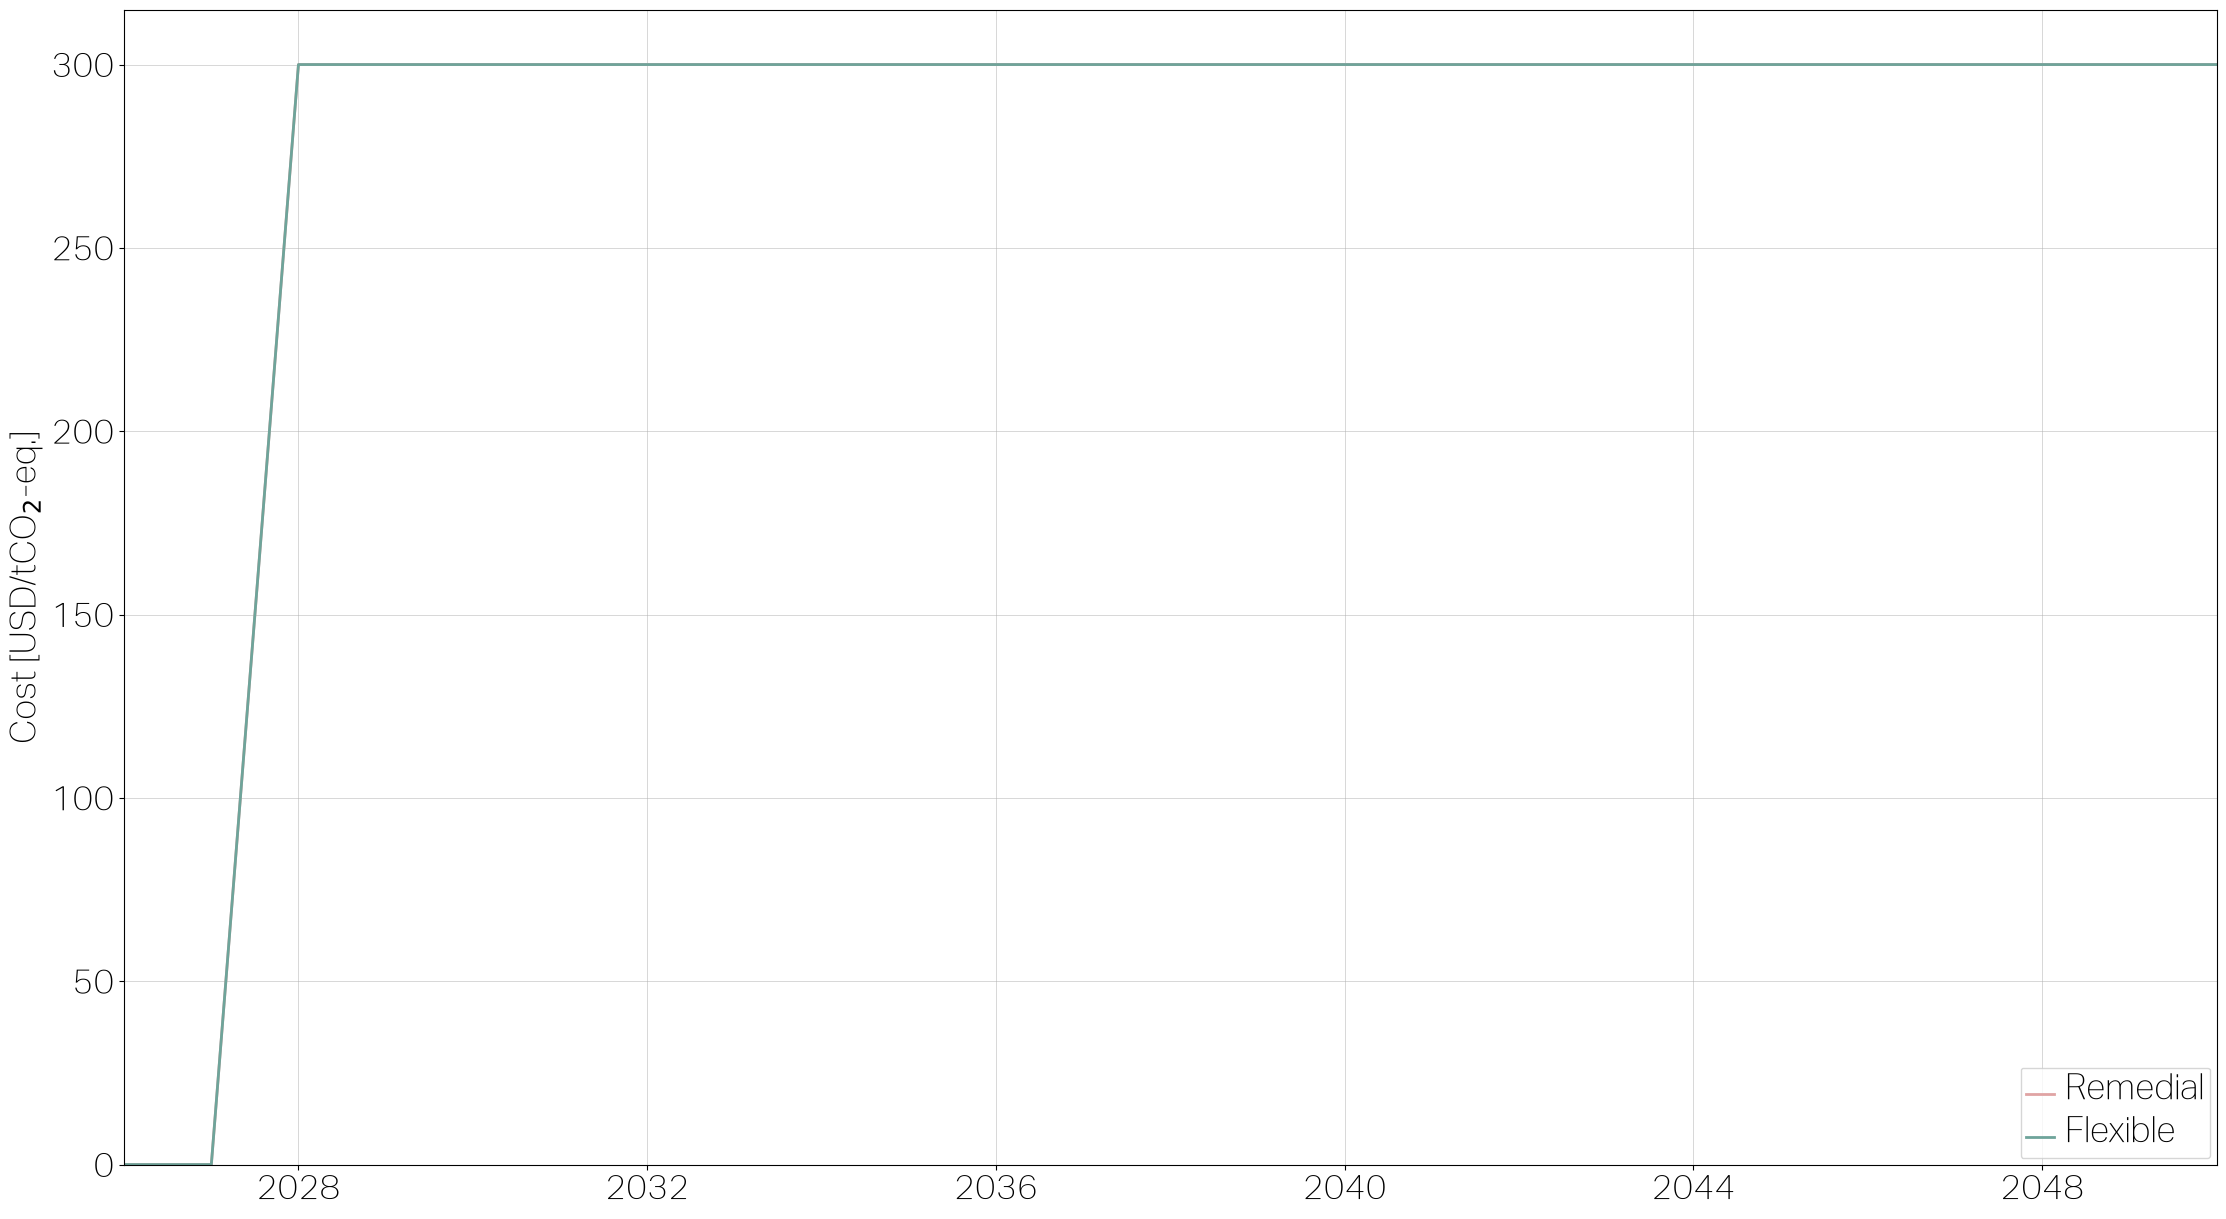

In [6]:
import glob
from IPython.display import Image, Markdown, display

plots_dir = f"simulations/scenarios/{scenario}/plots"
plot_files = sorted(glob.glob(f"{plots_dir}/*.png"))

if not plot_files:
    print(f"No .png plots found in {plots_dir} -- check what Navigate actually wrote there:")
    for root, dirs, files in os.walk(f"simulations/scenarios/{scenario}"):
        for fn in files:
            print(os.path.join(root, fn))
else:
    for p in plot_files:
        title = os.path.splitext(os.path.basename(p))[0].replace("_", " ").capitalize()
        display(Markdown(f"### {title}"))
        display(Image(filename=p))


## Inspect the exported assumptions

The `-e` flag exported the assumptions used for this run to Excel. Let's preview the sheet names and a first look at the data.

In [7]:
import glob
import pandas as pd

excel_files = glob.glob(f"simulations/scenarios/{scenario}/**/*.xlsx", recursive=True)
print("Exported Excel files found:")
for f in excel_files:
    print(" -", f)

workbook = f"simulations/scenarios/{scenario}/{scenario}_assumptions.xlsx"
if os.path.exists(workbook):
    xls = pd.ExcelFile(workbook)
    print("Sheets in", workbook, ":", xls.sheet_names)
    display(xls.parse(xls.sheet_names[0]).head())


Exported Excel files found:
 - simulations/scenarios/basecase_mid_regulation\basecase_mid_regulation_assumptions.xlsx
 - simulations/scenarios/basecase_mid_regulation\plots\basecase_mid_regulation_report_default.xlsx
Sheets in simulations/scenarios/basecase_mid_regulation/basecase_mid_regulation_assumptions.xlsx : ['Assumptions', 'Curves & Forecasts', 'Surfaces & Timetables']


,Node,Name,Parameter,Assignment Date,Value,Unit
0,Converter,propulsion_ice_ammonia_bulk_carrier_26k_dwt,CAPEX,2026-01-01,"Forecast(""propulsion_ammonia_capex"")",USD/MW
1,Converter,propulsion_ice_ammonia_bulk_carrier_26k_dwt,OPEX,2026-01-01,"Forecast(""propulsion_ammonia_opex"")",USD/MW/year
2,Converter,propulsion_ice_ammonia_bulk_carrier_26k_dwt,Replacement,2026-01-01,1,fraction
3,Converter,propulsion_ice_ammonia_bulk_carrier_26k_dwt,PowerCapacity,2026-01-01,6.6,MW
4,Converter,propulsion_ice_ammonia_bulk_carrier_26k_dwt,MinimumLoad,2026-01-01,0.2,fraction


## Compare the three scenarios

The plots above are one scenario at a time. This last section puts all three
next to each other.

It reads each run's `plot_data.pkl` rather than its exported PNGs. That is the
solved model itself — nodes, profiles and the dateline — so the same metric can
be recomputed identically for every scenario, and nothing has to be re-solved.
It is also the only view that works for a run that solved but whose plots were
not exported.

The three decks differ only in their regulation lines, so everything below is
attributable to regulatory stringency alone.

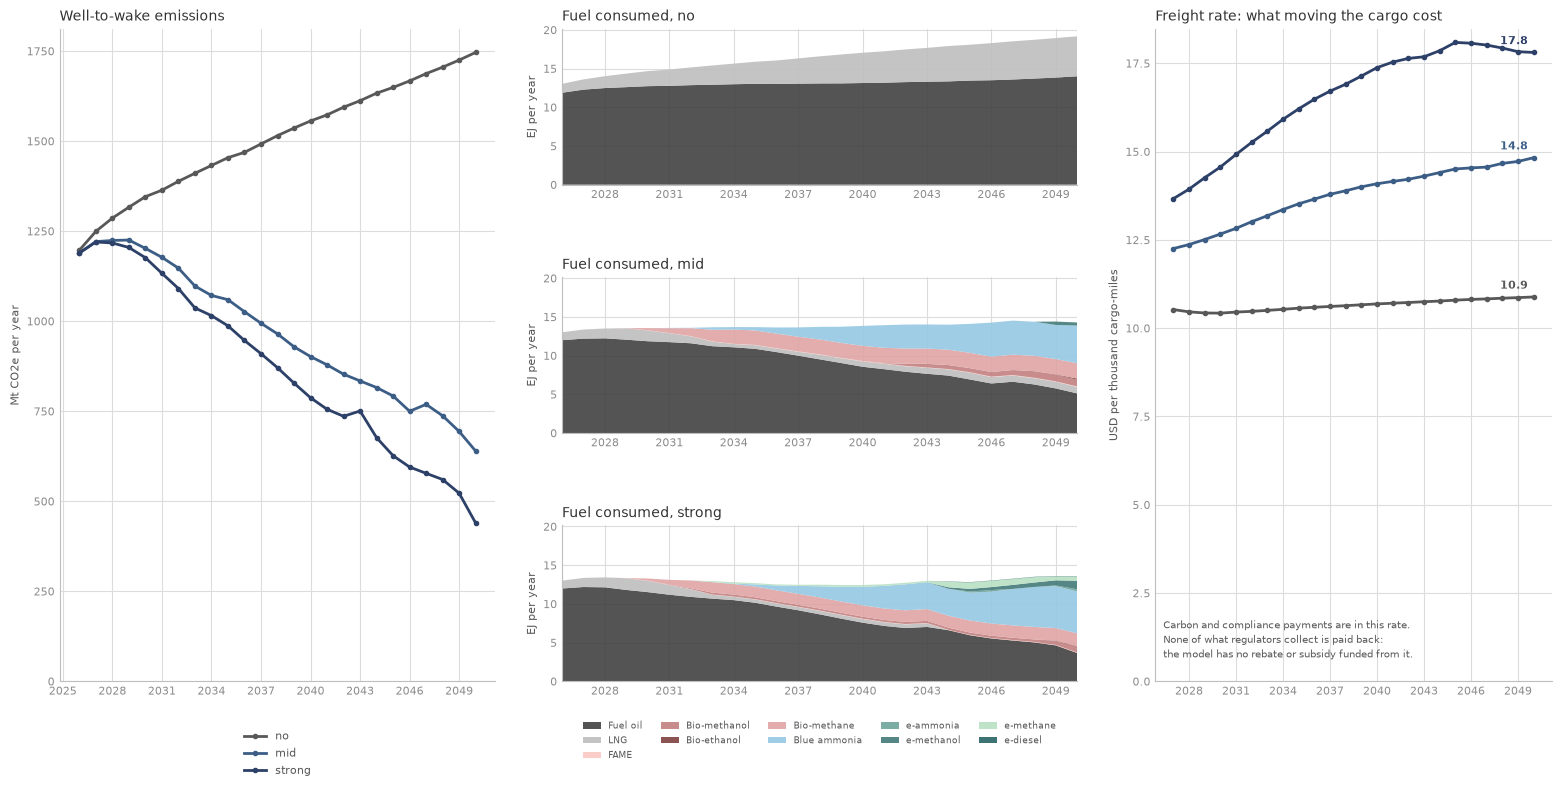

  scenario         WTW 2026   WTW 2050   cumulative  alt fuel 2050      freight 2050
                      Mt/yr      Mt/yr           Mt              %  USD/k cargo-mile
  no                  1,197      1,746       37,604            0.0              10.9
  mid                 1,189        639       24,193           58.3              14.8
  strong              1,189        439       21,851           73.1              17.8


In [8]:
import gzip
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Every run leaves its solved model on disk as a gzipped pickle, so comparing
# them costs nothing to redo. It is also the only view that works for every
# scenario: a run that solved but did not export its PNGs still has one of these.
COMPARE = ["basecase_no_regulation", "basecase_mid_regulation",
           "basecase_strong_regulation"]
SHORT = {s: s.replace("basecase_", "").replace("_regulation", "") for s in COMPARE}
FOSSIL = {"fossil_fuel_oil", "liquefied_natural_gas"}


def solved_model(scenario):
    with gzip.open(f"simulations/scenarios/{scenario}/plot_data.pkl", "rb") as fh:
        return pickle.load(fh)


def num(x):
    return np.nan_to_num(np.asarray(x, dtype=float))


solved = {}
for _s in COMPARE:
    if Path(f"simulations/scenarios/{_s}/plot_data.pkl").exists():
        solved[_s] = solved_model(_s)
    else:
        print(f"{_s}: no plot_data.pkl yet - run the cell above first")

if not solved:
    raise RuntimeError("no solved scenarios found; run them above before comparing")

# --- aggregate over all 23 fleets, the way notebook 5 does ------------------
# Same four series, so the two comparison figures can be read the same way:
# emissions, the fuel mix year by year, what the trade cost, and the share of
# alternatives at the end.
cases = {}
for s, d in solved.items():
    years = d.get_dateline().astype("datetime64[Y]").astype(int) + 1970
    total = np.zeros(len(years))
    rate_x_miles, miles = np.zeros(len(years)), np.zeros(len(years))
    by_year_raw, last_alt, last_all = {}, 0., 0.
    for fleet in d.nodes.fleets.values():
        total = total + num(fleet.profile.get_total_equivalent_WTW())
        cargo_miles = num(fleet.profile.get_cargo_miles())
        rate_x_miles = rate_x_miles + cargo_miles * num(
            fleet.profile.get_instantaneous_freight_rate())
        miles = miles + cargo_miles
        for fuel, series in fleet.profile.get_consumed_energy().items():
            values = num(series)
            by_year_raw[fuel] = by_year_raw.get(fuel, np.zeros(len(years))) + values
            last_all += float(values[-1])
            if fuel not in FOSSIL:
                last_alt += float(values[-1])
    cases[s] = {
        "years": years,
        "wtw": total / 1e6,                                # Mt CO2e per year
        # GJ -> EJ, stacked in Navigate's own fuel order
        "by_year": {f: by_year_raw[f] / 1e9 for f in fuel_sorted(by_year_raw)
                    if by_year_raw[f].sum() > 0},
        # the model's own instantaneous rate, weighted by the cargo-miles each
        # fleet moved, in the unit Navigate's fleet_investment_metric plot uses
        "freight": 1e3 * np.divide(rate_x_miles, miles,
                                   out=np.zeros_like(miles), where=miles > 0),
        "alt_last": 100. * last_alt / last_all if last_all else 0.,
    }

order = [s for s in COMPARE if s in cases]

# Emissions and cost span every row; the mix gets one row per scenario, on a
# shared scale, so the three can be read against each other rather than each
# filling its own panel. One colour per scenario, an ordered grey-to-blue ramp
# shared with the forecast chart further up, and deliberately not fuel colours:
# the middle column stacks fuels right beside them.
fig = plt.figure(figsize=(15.5, 7.8), constrained_layout=True)
grid = fig.add_gridspec(len(order), 3, width_ratios=[1.1, 1.3, 1.0],
                        hspace=.22, wspace=.06)
axE = fig.add_subplot(grid[:, 0])
axStack = [fig.add_subplot(grid[i, 1]) for i in range(len(order))]
for ax in axStack[1:]:
    ax.sharex(axStack[0])
    ax.sharey(axStack[0])
axC = fig.add_subplot(grid[:, 2])

for s in order:
    axE.plot(cases[s]["years"], cases[s]["wtw"], lw=2, marker=".", ms=6,
             label=SHORT[s], color=scen_colour(s))
axE.set_title("Well-to-wake emissions", fontsize=10, color=INK, loc="left")
axE.set_ylabel("Mt CO2e per year", fontsize=8, color=SUBINK)
axE.set_ylim(bottom=0.)
axE.legend(fontsize=8, frameon=False, labelcolor=SUBINK,
           loc="upper center", bbox_to_anchor=(0.5, -0.06), ncol=1)

fuels = fuel_sorted({f for c in cases.values() for f in c["by_year"]})
for ax, s in zip(axStack, order):
    stack = [cases[s]["by_year"].get(f, np.zeros(len(cases[s]["years"])))
             for f in fuels]
    ax.stackplot(cases[s]["years"], *stack, colors=[fuel_colour(f) for f in fuels],
                 labels=[fuel_label(f) for f in fuels], linewidth=0, alpha=.9)
    ax.set_title(f"Fuel consumed, {SHORT[s]}", fontsize=10, color=INK, loc="left")
    ax.set_ylabel("EJ per year", fontsize=8, color=SUBINK)
    ax.margins(x=0)
axStack[-1].legend(fontsize=6.5, frameon=False, labelcolor=SUBINK, ncol=5,
                   loc="upper center", bbox_to_anchor=(0.5, -0.20))

# step 0 takes no decisions, so the freight rate starts at the second step
for s in order:
    axC.plot(cases[s]["years"][1:], cases[s]["freight"][1:], lw=2, marker=".",
             ms=6, label=SHORT[s], color=scen_colour(s))
    axC.annotate(f"{cases[s]['freight'][-1]:,.1f}",
                 (cases[s]["years"][-1], cases[s]["freight"][-1]),
                 xytext=(-4, 6), textcoords="offset points", ha="right",
                 fontsize=8, color=scen_colour(s), fontweight="bold")
axC.set_title("Freight rate: what moving the cargo cost", fontsize=10,
              color=INK, loc="left")
axC.set_ylabel("USD per thousand cargo-miles", fontsize=8, color=SUBINK)
axC.set_ylim(bottom=0.)
# The rate carries what the fleet pays out and almost nothing it gets back:
# Navigate has no rebate or subsidy funded from what a regulator collects, so a
# scheme that recycled its revenue would sit lower than this.
axC.text(.02, .03,
         "Carbon and compliance payments are in this rate." + chr(10)
         + "None of what regulators collect is paid back:" + chr(10)
         + "the model has no rebate or subsidy funded from it.",
         transform=axC.transAxes, fontsize=7, color=SUBINK,
         va="bottom", ha="left", linespacing=1.5)

for ax in [axE, axC] + axStack:
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(color=GRID, lw=.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=TICK, labelsize=8, length=0)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)

plt.show()

print(f"  {'scenario':14} {'WTW 2026':>10} {'WTW 2050':>10} {'cumulative':>12} "
      f"{'alt fuel 2050':>14} {'freight 2050':>17}")
print(f"  {'':14} {'Mt/yr':>10} {'Mt/yr':>10} {'Mt':>12} {'%':>14} "
      f"{'USD/k cargo-mile':>17}")
for s in order:
    _c = cases[s]
    print(f"  {SHORT[s]:14} {_c['wtw'][0]:10,.0f} {_c['wtw'][-1]:10,.0f} "
          f"{_c['wtw'].sum():12,.0f} {_c['alt_last']:14.1f} "
          f"{_c['freight'][-1]:17,.1f}")
